---
title: Python - Pandas
subtitle: Statystyczna analiza danych z Pandas. Wynagrodzenia
author:
  - name: Krzysztof Molenda
    affiliations: URK/WIPiE/KIPLiIS
    email: krzysztof.molenda@urk.edu.pl
date: 2025/05/02
---

:::{admonition} Ważne
:class: warning

* Niniejsze ćwiczenie opracowane jest w formie interaktywnego notatnika Jupyter. W komórkach z tekstem wykorzystano MyST markdown.
* Należy zapoznawać się z treścią **po kolei**, uruchamiając kolejne komórki z kodem. Wszystkie kroki są szczegółowo wyjaśnione. W niektórych przypadkach pojawią się błędy (celowo), które są omawiane w treści ćwiczenia.
* Zawsze można zrestartować jądro Jupyter Notebooka i wyczyścić wszystkie wyniki obliczeń (komenda `Kernel -> Restart & Clear Output`). 
:::

Głównym celem ćwiczenia jest zaprezentowanie możliwości biblioteki języka Python i Pandas do przeprowadzania prostej analizy danych.

Zakłada się podstawową znajomość języka Python (podstawienie, warunkowy wybór, pętle, listy, słowniki) oraz podstawową umiejętność posługiwania sie notatnikiem Jupyter.

## Wprowadzenie

Pandas to biblioteka Pythona do analizy danych. Umożliwia łatwe manipulowanie danymi, ich przetwarzanie i wizualizację. W żargonie analityków danych nazywana jest programowalnym Excelem w środowisku Pythona.

W tym ćwiczeniu zapoznamy się z podstawowymi funkcjami biblioteki Pandas oraz z metodami analizy danych. Ćwiczenie obejmuje następujące zagadnienia:

* Wczytanie danych z pliku Excel
* Wstępna analiza danych
* Podstawowe operacje na danych
* Wizualizacja danych
* Analiza statystyczna danych i modelowanie

Ćwiczenie realizujemy wykorzystując środowisko Jupyter Notebook.

Podstawowym obiektem w Pandas jest _DataFrame_, który jest dwuwymiarową tabelą danych. _DataFrame_ można porównać do arkusza kalkulacyjnego, gdzie kolumny to zmienne, a wiersze to obserwacje. Pandas umożliwia łatwe manipulowanie danymi w _DataFrame_, takie jak filtrowanie, sortowanie, grupowanie i agregowanie danych. Wspiera również podstawowe obliczenia statystyczne i wizualizację danych.

::::{admonition} Dygresja - _DataFrame_
:class: dropdown

Trudno jest znaleźć idealny, pojedynczy zamiennik dla terminu "DataFrame" w języku polskim, który w pełni oddawałby jego znaczenie w kontekście programowania i analizy danych. "DataFrame" to specyficzna struktura danych z biblioteki Pandas w Pythonie, która organizuje dane w sposób tabelaryczny, z wierszami i kolumnami.

Oto kilka propozycji i wyjaśnień, dlaczego żadna nie jest idealna:

* **Ramka danych:** To chyba najczęściej używane tłumaczenie. Jest dość bliskie oryginałowi i w miarę zrozumiałe. Jednak "ramka" może sugerować coś statycznego, podczas gdy DataFrame jest obiektem, na którym wykonuje się operacje.
* **Tabela danych:** To tłumaczenie jest proste i intuicyjne. Oddaje tabelaryczną naturę DataFrame. Ale "tabela" w języku polskim często odnosi się do czegoś, co widzimy na ekranie lub w dokumencie, a DataFrame to obiekt w pamięci komputera.
* **Struktura danych tabelarycznych:** To tłumaczenie jest bardzo dokładne, ale długie i mało praktyczne w codziennym użyciu.
* **Tablica danych:** To tłumaczenie jest czasami używane, ale "tablica" w informatyce ma inne, bardziej specyficzne znaczenie (np. "array").

**W praktyce**

W większości przypadków programiści i analitycy danych w Polsce po prostu używają angielskiego terminu **"DataFrame"**. Jest to powszechnie zrozumiałe w środowisku.

**Podsumowując**

Chociaż istnieją próby tłumaczenia, żadne nie oddaje w pełni specyfiki i kontekstu "DataFrame". Dlatego w praktyce najczęściej używa się oryginalnego terminu.
::::

## Instalacja

:::{tip} Porada
Jesli używasz Google Colab, Anaconda, Jupyter Notebook czy JupyterLab/JupyterLite - biblioteka Pandas jest już zainstalowana. W przeciwnym razie, jeśli używasz lokalnej instalacji Pythona, musisz zainstalować Pandas samodzielnie.
:::

Aby zainstalować Pandas w lokalnym środowisku Pythona, należy użyć menedżera pakietów, np. `pip`. W terminalu należy wpisać:

```bash
pip install pandas
```

## Konfiguracja
Aby używać Pandas w Jupyter Notebook, należy zaimportować bibliotekę. W tym celu należy wpisać następujące polecenie:

```python
import pandas as pd
```

Do składników pakietu będziesz od tego momentu odwoływać się za pomocą _aliasu_ `pd`

In [ ]:
# instalacja biblioteki
# %pip install pandas #dla Pyodide
# %mamba install pandas # dla XPython

In [ ]:
# importowanie biblioteki, o ile jest zainstalowana
import pandas as pd

# wypisuje wersję biblioteki `pandas`
print(pd.__version__)

## Opis problemu

W pliku `wynagrodzenia.xlsx`, w arkuszu `Dane` znajdują się dane dotyczące wynagrodzeń pracowników w pewnej firmie. Dane są zanonimizowane i pochodzą sprzed wielu lat, stąd wartości wynagrodzenia mogą być nieaktualne. W pliku znajdują się dane dotyczące 1000 pracowników. 

W pliku tym mamy następujące kolumny:
* `Pracownik` - identyfikator pracownika, napis
* `Pensja` - wynagrodzenie pracownika, liczba zmiennoprzecinkowa
* `Staż pracy` - liczba lat pracy w firmie, liczba całkowita
* `Płeć` - płeć: `M` - mężczyzna, `K` - kobieta, napis

Celem ćwiczenia jest przeprowadzenie analizy danych dotyczących wynagrodzeń pracowników. W szczególności zależy nam na uzyskaniu informacji o:
* średnim wynagrodzeniu pracowników w firmie
* średnim wynagrodzeniu pracowników w zależności od płci, od stażu pracy
* rozkładzie wynagrodzeń pracowników (również w zależności od płci i stażu pracy)

Chcielibyśmy również uzyskać informacje o ewentualnie istniejących związkach między wynagrodzeniem a płcią oraz stażem pracy. W tym celu przeprowadzimy analizę statystyczną danych, w tym testy statystyczne i wizualizację danych.

## Wczytanie danych z pliku Excel

Pandas umożliwia wczytywanie danych z różnych źródeł, w tym z plików Excel, CSV, JSON, baz danych SQL i innych. W naszym przypadku dane znajdują się w pliku Excel, który zawiera arkusz z danymi.

Wczytanie danych z pliku Excel do obiektu typu `DataFrame` można wykonać za pomocą funkcji `pd.read_excel()`. Funkcja ta przyjmuje jako argument ścieżkę do pliku Excel oraz opcjonalnie nazwę arkusza, z którego chcemy wczytać dane. W naszym przypadku wczytamy dane z pliku `wynagrodzenia.xlsx`, który znajduje się w tym samym katalogu co nasz notatnik.

Do poprawnego działania funkcji `pd.read_excel()` potrzebny jest wcześniej zainstalowany pakiet `openpyxl`. Można go zainstalować w systemie za pomocą polecenia: `pip install openpyxl`.

In [ ]:
%pip install openpyxl

In [ ]:
# wczytanie danych z pliku Excel
dane = pd.read_excel('wynagrodzenia.xlsx', sheet_name='Dane')

Aby potwierdzić załadowanie danych z pliku do _DataFrame_, poleceniem `print()` wypiszemy kilka początkowych i końcowych wierszy wczytanych danych.

In [ ]:
print(dane)

W przypadku pracy z notatnikiem Jupyter, lepszym rozwiązaniem jest użycie polecenia `display()`, aby wyświetlić dane w formie interaktywnej tabeli.

::::{hint} Podpowiedź
:class: dropdown

Pracując z Jupyter Notebook
* warto używać polecenia `display()` zamiast `print()`, aby uzyskać lepszą wizualizację danych; funkcja `display()` wykrywa typ przekazanego obiektu i wyświetla go w odpowiedniej, najbardziej czytelnej formie;
* zamiast jawnie wywoływać funkcję `display()`, można w ostatniej linii komórki wpisać nazwę zmiennej, aby Jupyter automatycznie wywołał `display()` dla obiektu wskazywanego przez tę zmienną. Na przykład, zamiast 
    ```python
    display(dane)
    ```
  można wpisać po prostu 
    ```python
    dane
    ``` 
* funkcji `display()` używamy, jeśli w komórce mamy więcej niż jedną instrukcję - i chcemy wymusić wyświetlenie obiektu nie występującego w ostatnim wierszu kodu. Na przykład:
    ```python
    wynik1 = obliczenia1()
    display(wynik1)
    obiczenia2()
    display(obliczenia3())
    wynik = obliczenia4()
    wynik
    ```
::::

In [ ]:
# jawne wywołanie funkcji `display` z biblioteki IPython
display(dane)

# niejawne wywołanie funkcji `display`, ostatni obiekt w komórce
dane

W podsumowaniu wyświetlanej tabeli mamy informację, że dane zawierają 1000 wierszy i 4 kolumny. Wiersze odpowiadają pracownikom, a kolumny to zmienne: `Pracownik`, `Pensja`, `Staż pracy` i `Płeć`. Wiersze automatycznie ponumerowane zostały wewnętrznie od `0` do `999`. Ta nienazwana początkowa kolumna to **indeks**, który jest domyślnie generowany przez Pandas. Aby dowiedzieć się więcej o indeksach w naszym _DataFrame_, można użyć polecenia `dane.index`. W podobny sposób można sprawdzić, jakie są nazwy kolumn wczytanych danych, używając polecenia `dane.columns`. Wartości w kolumnach można sprawdzić za pomocą polecenia `dane.values`. Wartości w kolumnach są przechowywane w formie tablic biblioteki _NumPy._

In [ ]:
display(dane.index)

In [ ]:
display(dane.columns)

In [ ]:
display(dane.values)

**Zmiana indeksu tabeli**

Indeks można zmienić, np. na kolumnę `Pracownik`, używając polecenia `dane.set_index('Pracownik', inplace = True)`. Wówczas kolumna `Pracownik` stanie się indeksem _DataFrame_, a kolejne kolumny zawierać będą dane dotyczące pracowników.

In [ ]:
dane.set_index('Pracownik', inplace=True)
display(dane)
display(dane.index)
display(dane.columns)

:::{important} Ważne
* Parametr `inplace = True` oznacza, że zmiany zostaną wprowadzone bezpośrednio w _DataFrame_ `dane`. Jeśli nie użyjemy tego argumentu, zmiany zostaną wprowadzone w nowym _DataFrame_, a oryginalny _DataFrame_ pozostanie bez zmian.
* Numeracja wewnętrzna wierszy nadal będzie obowiazywała od `0` do `999`, ale kolumna `Pracownik` stanie się indeksem DataFrame. Numeracja wewnętrzna kolumn zmieni się - kolumną `0` będzie `Pensja`, kolumną `1` - `Staż pracy`, a kolumną `2` - `Płeć`.
:::

## Wstępna analiza i czyszczenie danych
Wstępna analiza danych polega na sprawdzeniu, czy dane są poprawne i czy nie zawierają błędów.

### Dostęp do danych



Obiekt typu `DataFrame` można traktować jak tablicę, gdzie kolumny to zmienne, a wiersze to obserwacje. Poniższy rysunek wyjaśnia znaczenie poszczególnych elementów _DataFrame_:

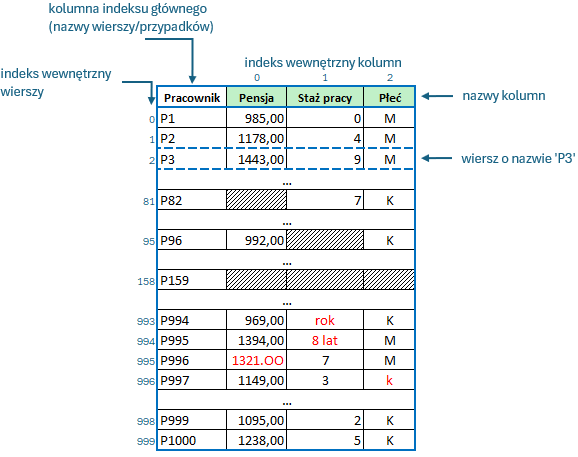

Wiersze i kolumny wewnętrznie indeksowane są liczbami od `0`. Czasami, za pośrednictwem tych indeksów możemy uzyskać dostęp do danych. Zdecydowanie lepszym i bezpieczniejszym sposobem jest odwoływanie się do do danych za pomocą nazw kolumn (zmiennych) czy nazw wierszy (przypadków/obserwacji).

Generalnie, aby odwołać się do elementu _DataFrame_, używamy operatora nawiasu kwadratowego `[]` - podobnie jak w Pythonie odwoływanie się do elementów słownika (nawiasem mówiąc, typ `DataFrame` przypomina swoją budową słownik).

#### Odwołania do kolumn

Aby odwołać się do konkretnej kolumny, używamy operatora `[]` i podajemy nazwę kolumny w cudzysłowie lub apostrofach. Na przykład, aby uzyskać dostęp do kolumny `Pensja`, używamy polecenia `dane['Pensja']`. 

In [ ]:
dane['Pensja']

Możemy również uzyskać dostęp do kilku kolumn jednocześnie, podając **listę nazw kolumn** (w nawiasach kwadratowych, jak w Pythonie). Na przykład, aby uzyskać dostęp do kolumn `Płeć` i `Pensja`, używamy polecenia `dane[['Płeć', 'Pensja']]` - przekazując listę nazw kolumn w oczekiwanej kolejności.

In [ ]:
dane[['Płeć', 'Pensja']]

::::{important} Ważne

Wynikiem odwołania się do elementu _DataFrame_ za pomocą operatora `[]` jest **nowy obiekt** (`Series` lub `DataFrame`), który zawiera tylko te dane, do których się odwołaliśmy. Wartości w tym nowym obiekcie są kopiowane z oryginalnego _DataFrame_. Wszelkie zmiany wprowadzone w tym nowym obiekcie nie wpłyną na oryginalny _DataFrame_.

Jeśli chcemy produkowane dane zapamiętać w nowym obiekcie, zapiszemy je w zmiennej. Na przykład, aby zapisać kolumnę `Pensja` w zmiennej `pensje`, używamy polecenia `pensje = dane['Pensja']`. Wówczas zmienna `pensje` będzie zawierała kopię kolumny `Pensja` z oryginalnego DataFrame.
::::

In [ ]:
pensje = dane['Pensja']
pensje

:::{tip} Porada
:class: dropdown

Jeśli nazwy kolumn są poprawnymi identyfikatorami Pythona, można uzyskać dostęp do kolumny bez użycia operatora `[]`, a za pomocą operatora wyłuskania `.` 

Na przykład, aby uzyskać dostęp do kolumny `Pensja`, można użyć polecenia `dane.Pensja`. Podobnie z uzyskaniem dostępu do kilku kolumn jednocześnie - można użyć polecenia `dane[['Płeć', 'Pensja']]` lub `dane.Płeć, dane.Pensja`.

Jednakże, jeśli nazwa kolumny zawiera spacje lub inne znaki specjalne, nie można użyć operatora `.` do uzyskania dostępu do kolumny. Na przykład, aby uzyskać dostęp do kolumny `Staż pracy`, nie można użyć polecenia `dane.Staż pracy`, ponieważ zawiera ono spację.
:::

In [ ]:
display(dane.Płeć, dane.Pensja)

#### Odwołania `loc` oraz `iloc`

Ze względu na to, że _DataFrame_ dysponuje wieloma sposobami indeksowania jego danych, wprowadzono uniwersalny sposób odwoływania się do danych w _DataFrame_ - za pomocą metod `loc[]` oraz `iloc[]`. 

* Metoda `loc[]` służy do indeksowania danych na podstawie etykiet (indeksów)
* Metoda `iloc[]` służy do indeksowania danych na podstawie pozycji (indeksów liczbowych, wewnętrznych).

Zarówno `loc[]` jak i `iloc[]` można używać do uzyskiwania dostępu do pojedynczych wartości, wierszy, kolumn lub podzbiorów danych w _DataFrame_.

#### Odwołanie do wierszy

**Odwołania pozycyjne**

Aby uzyskać dostęp do konkretnego wiersza, używamy operatora `iloc[]` i podajemy numer wiersza (numeracja wewnętrzna, od `0`). Na przykład, aby uzyskać dostęp do pierwszego wiersza, używamy polecenia `dane.iloc[0]`. Możemy również uzyskać dostęp do kilku wierszy jednocześnie, podając **listę numerów wierszy**. Na przykład, aby uzyskać dostęp do pierwszych pięciu wierszy, używamy polecenia `dane.iloc[[0, 1, 2, 3, 4]]`.

In [ ]:
display(dane.iloc[0])

In [ ]:
display(dane.iloc[[0, 2, 4, 6]])

Nic nie stoi na przeszkodzie, aby używać slicerów. Na przykład, aby uzyskać dostęp do pierwszych pięciu wierszy, można użyć polecenia `dane.iloc[0:5]`. Można również użyć operatora `:` do uzyskania dostępu do wszystkich wierszy (`dane.iloc[:]`) lub do ostatnich dwóch wierszy (`dane.iloc[-2:]`).

:::{important} Ważne
Fragmentacja (ang. _slicing_) w Pandas w nawiasach `[]` **działa dla wierszy**.
:::

In [ ]:
display(dane.iloc[0:5])
display(dane.iloc[-2:])

**Odwołania przez nazwy**

Drugi wariant, metoda `loc[]`, działa podobnie, ale zamiast numerów wierszy używamy etykiet (indeksów). Na przykład, aby uzyskać dostęp do pierwszego wpisu użyjemy polecenia `dane.loc['P1']`. Możemy również uzyskać dostęp do kilku wierszy jednocześnie, podając **listę etykiet**. Na przykład, aby uzyskać dostęp do co drugiego wiersza od `P1` do `P7`, używamy polecenia `dane.loc[['P1', 'P3', 'P5', 'P7']]` lub z wykorzystaniem slicera `dane.loc['P1':'P7':2]`.

In [ ]:
print("czy loc['P1'] == iloc[0]?")
display(dane.loc["P1"] == dane.iloc[0])

In [ ]:
dane.loc[['P1', 'P3', 'P5', 'P7']]

In [ ]:
dane.loc['P1':'P7':2]

:::{important} Ważne
Slicery dla `loc[]` działają od pierwszego do ostatniego wskazanego elementu. Oznacza to, że w przypadku `loc[]` **ostatnia etykieta jest również brana pod uwagę**, podczas gdy w przypadku `iloc[]` ostatnia etykieta nie jest brana pod uwagę (jak w czystym Pythonie).
:::

#### Odwołania do pojedynczej komórki

Aby uzyskać dostęp do konkretnej komórki, używamy operatora `iloc[]` i podajemy numer wiersza oraz numer kolumny. Na przykład, aby uzyskać dostęp do pierwszej komórki w pierwszym wierszu, używamy polecenia `dane.iloc[0, 0]`.

In [ ]:
display(dane.iloc[0,0])

Analogicznie, posługując się indeksami, używamy metody `loc[]` podając nazwę wiersza i kolumny. Na przykład, aby uzyskać dostęp do pierwszej komórki w pierwszym wierszu, używamy polecenia `dane.loc['P1', 'Pensja']`.

In [ ]:
dane.loc['P1', 'Pensja']

:::{important} Ważne

Odwołanie do elementów _DataFrame_, za pomocą indeksów wewnętrznych (liczbowych) oraz etykiet (indeksów) zgłosi błąd `IndexError`, `KeyError` lub `TypeError`, jeśli podany indeks lub etykieta nie istnieje.

Na przykład, jeśli próbujemy uzyskać dostęp 
* do wiersza o indeksie `1000`, zgłoszony zostanie błąd `IndexError`,
* do wiersza o etykiecie `P1000`, zgłoszony zostanie błąd `KeyError`,
* do kolumny o indeksie `4`, zgłoszony zostanie błąd `IndexError`,
* do kolumny o nazwie `Pensja1`, zgłoszony zostanie błąd `TypeError`.

W takim przypadku należy sprawdzić, czy podany indeks/etykieta istnieje w _DataFrame_ - używając polecenia `dane.index` lub `dane.columns`.

In [ ]:
# dane.iloc[1000, 0]  # niepoprawne, bo nie ma wiersza o indeksie 1000
# dane.loc['P1001', 'Pensja']  # niepoprawne, bo nie ma wiersza o indeksie 'P1001'
# dane.iloc[0, 4]  # niepoprawne, bo nie ma kolumny o indeksie 4
# dane.loc('P1', 'Pensja1')  # niepoprawne, bo nie ma kolumny o nazwie 'Pensja1'

:::{important} Ważne
Nie wolno mieszać indeksów i etykiet. Na przykład, jeśli próbujemy uzyskać dostęp do wiersza o indeksie `0` i kolumny o nazwie `Pensja` (`dane.iloc[0, 'Pensja']` lub `dane.loc[0,'Pensja']`), zgłoszony zostanie błąd `TypeError`, `ValueError` lub `KeyError`. Należy używać albo indeksów, albo etykiet - nie można ich mieszać.
:::

In [ ]:
# dane.iloc[0, 'Pensja'] # niepoprawne, bo iloc wymaga indeksu liczbowego, ValueError
# dane.loc[0, 'Pensja']  # niepoprawne, bo nie ma wiersza o indeksie/etykiecie `0`, KeyError
# dane.loc["P1", 0]  # niepoprawne, bo nie ma kolumny o etykiecie `0`, KeyError

:::{tip} Porada
Dostep do pojedynczej komórki można również uzyskać za pomocą operatora `at[]` oraz `iat[]`. Na przykład, aby uzyskać dostęp do pierwszej komórki w pierwszym wierszu, użyjemy polecenia `dane.at['P1', 'Pensja']` lub `dane.iat[0, 0]`.
:::

In [ ]:
display(dane.at['P1', 'Pensja'])
display(dane.iat[0, 0])

#### Odwołania do podzbiorów danych

Aby uzyskać dostęp do podzbioru danych, używamy operatora `iloc[]` i podajemy zakres wierszy oraz kolumn. Na przykład, aby uzyskać dostęp do pięciu wierszy począwszy od wiersza `100` oraz kolumn `Pensja` i `Płeć`, używamy polecenia `dane.iloc[100:105, [0, 2]]`.

In [ ]:
dane.iloc[100:105, [0, 2]]

Załóżmy, że chcemy wyświetlić dane dotyczące konkretnych pracowników, których mamy zapamietanych w oddzielnej liście. Wówczas możemy użyć metody `loc[]` i podać tę listę etykiet.

In [ ]:
lista_pracownikow_do_analizy = ['P101', 'P3', 'P25', 'P97']
dane.loc[lista_pracownikow_do_analizy, ['Płeć', 'Pensja']]

#### Odwołania - podsumowanie

`DataFrame` można traktować jak tablicę, gdzie kolumny to zmienne, a wiersze to obserwacje. Formalnie, kolumny traktowane są jako serie danych jednego typu, a wiersze jako serie danych różnych typów - w tym celu w Pandas zdefiniowano specjalny typ `Series` jako typ danych jednego wymiaru (jednowymiarowa `DateFrame`).

Możemy uzyskać dostęp do danych w `DataFrame` na kilka sposobów:
* `dane['Pensja']` - dostęp do kolumny `Pensja` (jako `Series`). Również `dane.Pensja` - dostęp do kolumny `Pensja` (jako `Series`).
* `dane[['Pensja', 'Płeć']]` - dostęp do kolumn `Pensja` i `Płeć` (jako `DataFrame`)
* `dane.iloc[0]` - dostęp do pierwszego wiersza (jako `Series`)
* `dane.iloc[[0, 1, 2]]` - dostęp do pierwszych trzech wierszy (jako `DataFrame`)
* `dane.iloc[0:3]` - dostęp do pierwszych trzech wierszy (jako `DataFrame`) - wiersze o indeksach wewnętrznych `0`, `1` i `2`
* `dane.iloc[0, 0]` - dostęp do pierwszej komórki (jako wartość skalarna `float`)
* `dane.iloc[0:3, 0:2]` - dostęp do pierwszych trzech wierszy i pierwszych dwóch kolumn (jako `DataFrame`)
* `dane.loc['P1']` - dostęp do wiersza o etykiecie `P1` (jako `Series`)
* `dane.loc[['P1', 'P2']]` - dostęp do wierszy o etykietach `P1` i `P2` (jako `DataFrame`)
* `dane.loc['P1':'P3']` - dostęp do wierszy o etykietach od `P1` do `P3` włącznie (jako `DataFrame`)
* `dane.loc['P1', 'Pensja']` - dostęp do komórki o etykiecie `P1` i kolumnie `Pensja` (jako wartość skalarna `float`)
* `dane.loc[['P1', 'P2'], ['Pensja', 'Płeć']]` - dostęp do komórek o etykietach `P1` i `P2` oraz kolumnach `Pensja` i `Płeć` (jako `DataFrame`)
* `dane.loc['P1':'P3', 'Pensja':'Płeć']` - dostęp do komórek o etykietach od `P1` do `P3` włącznie oraz kolumnach od `Pensja` do `Płeć` włącznie (jako `DataFrame`)

Dostep do danych potrzebny jest nam do wyszukiwania informacji jak i ewentualnej ich edycji.

W przypadku, gdybyśmy chcieli zmienić wartość w kolumnie `Pensja` dla pracownika o etykiecie `P1` na kwotę 10000, użyjemy polecenia `dane.loc['P1', 'Pensja'] = 10000`.

### Filtrowanie danych

Filtrowanie danych polega na wybraniu tylko tych wierszy, które spełniają określone warunki. W Pandas można filtrować dane za pomocą operatorów porównania (`==`, `!=`, `<`, `>`, `<=`, `>=`) oraz operatorów logicznych (`&`, `|`, `~`).

:::{important} Zapamiętaj

W Pandas do definiowania filtrowania używamy dedykowanych operatorów logicznych:
* `&` - operator AND (i)
* `|` - operator OR (lub)
* `~` - operator NOT (nie)

⚠ Przy budowaniu warunków filtrujących **nie używamy** operatorów `and`, `or`, `not` - są to operatory Pythona, które nie działają na obiektach Pandas. Użycie tych operatorów zgłosi błąd `ValueError` lub `TypeError`.
:::

::::{admonition} Przykład

Chcesz uzyskać dostęp do wszystkich pracowników którzy są kobietami i którzy mają wynagrodzenie większe niż `5000`. W tym celu użyjemy operatora `&` oraz operatorów porównania. 

```python
dane[(dane['Płeć'] == 'K') & (dane['Pensja'] > 5000)]
```
::::

::::{admonition} Przykład

Chcesz uzyskać dostęp do wszystkich pracowników, którzy są mężczyznami lub ich wynagrodzenie mieści się w przedziale `5000` - `10000`. W tym celu użyjemy operatora `|` oraz operatorów porównania.

```python
dane[(dane['Płeć'] == 'M') | ((dane['Pensja'] >= 5000) & (dane['Pensja'] <= 10000))]
```
::::

**Jak to działa?**

W Pandas filtrowanie danych działa na zasadzie maski. Maska to tablica wartości logicznych (`True`/`False`), która wskazuje, które wiersze powinny zostać wybrane. Wartości `True` oznaczają, że dany wiersz spełnia warunek, a wartości `False` oznaczają, że dany wiersz nie spełnia warunku.

Maska jest tworzona na podstawie warunków, które definiujemy. Na przykład, jeśli chcemy wybrać tylko te wiersze, w których w kolumnie `Płeć` jest wpisane `K`, używamy następującego polecenia:

```python
maska = (dane.Płeć == 'K')
```

Wówczas zmienna `maska` będzie zawierała tablicę wartości logicznych, która wskazuje, które wiersze spełniają warunek.

```python
maska
```
    
```output
0     False
1     False
...
999   True
Name: Płeć, dtype: bool
```

Następnie możemy użyć tej maski do filtrowania danych:

```python
dane[maska]
```

Pandas łaczy dane z maską i jako wynik zwraca tylko te wiersze, dla których maska jest `True`.

Nie musimy jednak tworzyć maski, aby filtrować dane. Możemy od razu użyć warunków w nawiasach kwadratowych:

```python
dane[dane.Płeć == 'K']
```

In [ ]:
maska = (dane.Płeć == 'K')
display(maska)
display(dane[maska])

In [ ]:
dane[dane.Płeć == 'K']

Wprowadzając polecenie `dane[dane.Płeć == 'K']`, Pandas automatycznie tworzy maskę na podstawie warunków, które podajemy w nawiasach kwadratowych. Następnie używa tej maski do filtrowania danych.

Problem może pojawić się w sytuacji, gdy nie można poprawnie wyznaczyć maski. Na przykład chcemy wyznaczyć tych pracowników, których wynagrodzenie jest większe niż `5000`. Filtrujemy dane w następujący sposób:

```python
dane[dane.Pensja > 5000]
```

W pierwszej kolejności Pandas tworzy maskę, która wskazuje, które wiersze spełniają podany warunek. 

* Jeśli w kolumnie `Pensja` znajdują się wartości `NaN`, Pandas nie będzie w stanie poprawnie wyznaczyć maski i zgłosi błąd `ValueError`. W takim przypadku należy najpierw usunąć wartości `NaN` z kolumny `Pensja`, a następnie ponownie wykonać filtrowanie.
* Jeśli w kolumnie `Pensja` znajdują się wartości inne niż liczby (na przykład napisy), Pandas również nie będzie w stanie poprawnie wyznaczyć maski i zgłosi błąd `TypeError`. W takim przypadku należy najpierw sprawdzić, czy w kolumnie `Pensja` znajdują się wartości inne niż liczby, a następnie ponownie wykonać filtrowanie.

In [ ]:
# ten kod zgłosi błąd, działanie celowe
dane[dane.Pensja > 5000]

Problemy związane z przygotowaniem danych do obliczeń omówione zostaną przy okazji analizy poszczególnych zmiennych.

### Typy danych. Czyszczenie danych

Każda kolumna w `DataFrame` ma przypisany typ danych.

* W naszym przypadku kolumna `Pensja` powinna mieć typ `float` (lub `float64`), ponieważ wynagrodzenie jest liczbą zmiennoprzecinkową. 
* Kolumna `Staż pracy` powinna mieć typ `int` (lub `int64`), ponieważ staż pracy jest liczbą całkowitą. 
* Kolumna `Płeć` powinna mieć typ `object`, ponieważ zawiera dane tekstowe (napisy) - `K` płeć żeńska, `M` - płeć męska.
* Kolumna indeksu `Pracownik` powinna mieć typ `object`, ponieważ zawiera dane tekstowe (napisy) - identyfikatory pracowników.

Typy danych można sprawdzić za pomocą polecenia `dane.dtypes`.

In [ ]:
dane.dtypes

:::{important} Ważne
Jeśli kolumna zawiera dane tekstowe, Pandas domyślnie przypisuje jej typ `object`. Zatem w przypadku, gdy oczekujemy, że kolumna powinna zawierać liczby całkowite, a Pandas przypisze jej typ `object`, oznacza to, że kolumna zawiera dane tekstowe. W tej sytuacji należy sprawdzić, czy w kolumnie nie ma błędnych danych (np. liter zamiast liczb).
:::

W zaimportowanych danych kolumny `Pensja` i `Staż pracy` mają typ `object`, a oczekiwaliśmy liczb. Oznacza to, że zawierają one dane tekstowe - w kolumnach tych mogą znajdować się błędne dane (np. litery zamiast liczb). Należy sprawdzić, czy w kolumnach tych nie ma błędnych danych.

Podstawowym poleceniem pozwalającym na całościowy przegląd danych w _DataFrame_ jest polecenie `dane.info()`. Polecenie to wyświetla informacje o liczbie wierszy, kolumnach, typach danych oraz liczbie niepustych wartości w każdej kolumnie. 

Wartości puste są oznaczone jako `NaN` (ang. _Not a Number_) dla typów liczbowych, `Null` dla typów obiektowych i `NaT` (ang. _Not a Time_) dla typów daty i czasu. Wartości puste mogą występować w przypadku, gdy dane są niekompletne lub brakuje ich w źródle danych.

In [ ]:
dane.info()

Z powyższego wydruku wynika, że:

* zaindeksowane jest 1000 wierszy (od `P1` do `P1000`) i 3 kolumny (`Pensja`, `Staż pracy` i `Płeć`)
* kolumna `Pensja` zawiera 998 niepustych wartości, czyli 2 wartości puste (`NaN`), ale ma typ `object`, co oznacza, że zawiera dane tekstowe (np. litery zamiast liczb)
* kolumna `Staż pracy` podobnie, zawiera 998 niepustych wartości, ale ma typ `object`, co oznacza, że zawiera dane tekstowe (np. litery zamiast liczb)
* kolumna `Płeć` zawiera 999 niepustych wartości, ma typ `object` zgodnie z oczekiwaniami.

Naszym celem będzie "naprawienie" danych - uzupełnienie brakujących wartości oraz zmiana typów danych w kolumnach `Pensja` i `Staż pracy` na właściwe.

#### Kolumna `Pensja`

Aby sprawdzić, jakie wartości znajdują się w kolumnie `Pensja`, możemy użyć polecenia `dane['Pensja'].unique()` zwracającego unikalne wartości w tej kolumnie. W naszym przypadku polecenie to nie ma sensu, ponieważ unikalnych wartości jest zbyt wiele.

In [ ]:
dane['Pensja'].unique()

Możemy również użyć polecenia `dane['Pensja'].value_counts()`, które zwraca liczbę wystąpień każdej unikalnej wartości w kolumnie `Pensja`. 

In [ ]:
dane['Pensja'].value_counts()

W tym przypadku również nie otrzymujemy sensownej odpowiedzi - jest zbyt wiele unikalnych wartości, nie wszystkie mieszczą się na wydruku.

Chcemy zawęzić wydruk tylko do tych wartości w kolumnie `Pensja`, które są błędne - brak danych. W tym celu możemy użyć polecenia `maska = dane['Pensja'].isna()`, które zwraca maskę logiczną (True/False) dla każdej wartości w kolumnie `Pensja`. Każdemu wierszowi odpowiada wartość `True`, jeśli wartość w kolumnie `Pensja` jest pusta (`NaN`), a `False`, jeśli wartość jest niepusta.

Maskę tę możemy wykorzystać do filtrowania danych w kolumnie `Pensja`.

In [ ]:
maska_brak_danych = dane['Pensja'].isna()
display(dane[maska_brak_danych == True])

Zauważamy, że w dwóch przypadkach (`P82` i `P159`) w kolumnie `Pensja` znajdują się wartości `NaN`. Ponadto, dla wiersza `P159`, nie ma żadnych danych (być może pracownik został zwolniony).

Podejmujemy decyzje:

1. usuwamy wiersz `P159` z _DataFrame_, ponieważ nie ma żadnych danych dotyczących tego pracownika (wszystkie wartości są puste)
2. dla pracownika `P82` uzupełniamy brakującą wartość w kolumnie `Pensja` na `-999`, ponieważ nie możemy ustalić, jakie wynagrodzenie powinien mieć ten pracownik. Umawiamy się, że wartość `-999` oznacza, że nie mamy danych dotyczących tego pracownika. W późniejszych krokach zmienimy tę wartość na bardziej realistyczną (np. średnią pensję lub medianę pensji dla grupy pracowników).
3. zmieniamy typ danych w kolumnie `Pensja` z `object` na `float`, aby Pandas mógł poprawnie interpretować dane finansowe w tej kolumnie.

```python
# usuwamy wiersz P159
dane = dane[dane.index != 'P159']
# uzupełniamy brakującą wartość w kolumnie Pensja na -999
dane.loc['P82', 'Pensja'] = -999
# zmieniamy typ danych w kolumnie Pensja na float
dane['Pensja'] = dane['Pensja'].astype(float)
```

**Ad. 1.** W Pandas, aby usunąć wiersz z _DataFrame_, można użyć metody `drop()`. Metoda ta przyjmuje jako argument etykietę wiersza, który chcemy usunąć. W naszym przypadku usuwamy wiersz o etykiecie `P159`. Możemy to wykonać na dwa sposoby:

* używając metody `drop()` i podając etykietę wiersza, który chcemy usunąć, oraz argument `inplace = True`, aby zmiany zostały wprowadzone bezpośrednio w _DataFrame_ `dane`:

    ```python
    dane.drop('P159', inplace = True) 
    ```

* lub używając metody `drop()` i przypisując wynik do zmiennej `dane` (nadpisując oryginalny _DataFrame_):

    ```python
    dane = dane.drop('P159')
    ```

::::{note} Zanotuj
Polecenie `dane.drop('P159')` nie zmienia oryginalnego _DataFrame_ `dane`, ale zwraca nowy _DataFrame_ bez wiersza o etykiecie `P159`. Aby zmiany zostały wprowadzone w oryginalnym _DataFrame_, należy użyć argumentu `inplace = True` lub przypisać wynik do nowego _DataFrame_ (np. `dane = dane.drop('P159')`).

Ten drugi sposób jest bardziej elastyczny, ponieważ pozwala na utworzenie nowego _DataFrame_ bez zmiany oryginalnego _DataFrame_. Na przykład możemy utworzyć nowy _DataFrame_ bez wiersza o etykiecie `P159` i przypisać go do zmiennej `dane2`:

```python
dane2 = dane.drop('P159')
```
::::

Do modyfikowania _DataFrame_ często używamy filtrowania i nadpisania oryginalnego _DataFrame_ wynikiem filtrowania. W naszym przypadku, aby usunąć wiersz o etykiecie `P159`, możemy użyć operatora `!=` do filtrowania danych i usunięcia wiersza o etykiecie `P159`. Wówczas otrzymujemy nowy _DataFrame_ bez tego wiersza:

```python
dane = dane[dane.index != 'P159']
```

Sposób ten warto stosować, jeśli mamy wiele wierszy do usunięcia, które można opisać warunkami logicznymi. Na przykład, aby usunąć wiersze dla których `Pensja` jest mniejsza niż `1000` napiszemy:

```python
dane = dane[dane['Pensja'] >= 1000]
```

In [ ]:
# usuwamy wiersz o indeksie 'P159' z oryginalnych danych
dane.drop('P159', inplace = True)

# sprawdzamy, czy wiersz o indeksie 'P159' został usunięty
print(dane[dane.index == 'P159'])

**Ad. 2.** Zmiana wartości w _DataFrame_ polega na przypisaniu nowej wartości do konkretnej komórki. W naszym przypadku zmieniamy wartość w kolumnie `Pensja` dla pracownika o etykiecie `P82` na `-999`. Użyjemy metody `loc[]` podając etykietę wiersza oraz nazwę kolumny, do której chcemy przypisać nową wartość:

```python
dane.loc['P82', 'Pensja'] = -999
```

In [ ]:
dane.loc['P82', 'Pensja'] = -999

# sprawdzamy, czy wiersz o indeksie 'P82' został zmieniony
print(dane[dane.index == 'P82'])

**Ad. 3.** Zmiana typu danych w kolumnie `Pensja` polega na użyciu metody `astype()`, która zmienia typ danych w kolumnie na podany typ w parametrze metody. Aktualnie kolumna `Pensja` ma typ `object`, co oznacza, że zawiera dane tekstowe (np. litery zamiast liczb).

W naszym przypadku napiszemy:

```python
dane['Pensja'] = dane['Pensja'].astype(float)
```

Powyższy kod zmienia typ danych w kolumnie `Pensja` na `float` a nastepnie podmienia oryginalny _DataFrame_ `dane` nowym _DataFrame_ z kolumną `Pensja` o typie `float`.

Operacja konwersji typu danych polega na przeglądnięciu danych w kolumnie i próbie ich konwersji na nowy typ. Jeśli konwersja się powiedzie, kolumna zostanie zmieniona na nowy typ. W przeciwnym razie zgłoszony zostanie błąd `ValueError` lub `TypeError` z dodatkowymi informacjami, które umożliwią Ci ustalenie przyczyny błędu konwersji. Braki danych (`NaN`) są ignorowane, a ich typ pozostaje bez zmian.

In [ ]:
# ten kod zgłosi błąd, celowe działanie
dane['Pensja'] = dane['Pensja'].astype(float)

Operacja konwersji nie powiodła się - zgłoszony został błąd `ValueError`. Na końcu komunikatu o błędzie wskazana jest przyczyna: "ValueError: could not convert string to float: '1321.OO'".

Oznacza to, że w kolumnie `Pensja` znajduje się wartość `1321.OO`, która nie może zostać przekonwertowana na typ `float`. Wartość ta zawiera litery `OO` a nie cyfry `00`. Należy je usunąć, aby konwersja się powiodła.

Najpierw musimy zlokalizować wiersz, w którym znajduje się ta wartość. Możemy to zrobić za pomocą polecenia `dane[dane['Pensja'] == "1321.OO"]`, które zwraca wiersz, w którym znajduje się ta wartość.

In [ ]:
dane[dane['Pensja'] == "1321.OO"]

W wierszu `P996` znajduje się wartość tekstowa `"1321.OO"`, która nie może zostać przekonwertowana na typ `float`.

In [ ]:
x = dane.loc['P996', 'Pensja']
display(x, type(x))

Podmienimy błędną wartość `"1321.OO"` na poprawną `1321.00` w kolumnie `Pensja` dla pracownika o etykiecie `P996`. Użyjemy metody `loc[]` podając etykietę wiersza oraz nazwę kolumny, do której chcemy przypisać nową wartość:

In [ ]:
dane.loc['P996', 'Pensja'] = 1321.00
display(dane.loc['P996', 'Pensja'], type(dane.loc['P996', 'Pensja']))

Po wykonaniu tej korekty możemy ponownie przystąpić do konwertowania kolumny `Pensja` na typ `float`.

In [ ]:
dane['Pensja'] = dane['Pensja'].astype(float)

Polecenie wykonane bez błędów. Uzyskajmy informacje na temat tej kolumny:

In [ ]:
display(dane.Pensja.info())

Z wydruku wynika, że `Pensja` jest serią danych typu `float64`. Ponadto, kolumna zawiera 999 niepustych wartości (indeksowanych nazwami od `P1` do `P1000`), co oznacza, że wszystkie wartości w tej kolumnie są liczbami zmiennoprzecinkowymi. Wartości puste (`NaN`) zostały usunięte lub uzupełnione.

Podstawowe statystyki dla kolumny `Pensja` można uzyskać za pomocą polecenia `dane['Pensja'].describe()`. Polecenie to zwraca podstawowe statystyki, takie jak liczba niepustych wartości, średnia, odchylenie standardowe, minimum, maksimum oraz kwartyle.

In [ ]:
display(dane.Pensja.describe())

W przypadku wynagrodzenia, lepszą miarą tendencji centralnej jest mediana, ponieważ nie jest ona wrażliwa na wartości odstające (np. bardzo wysokie lub bardzo niskie wynagrodzenia). Mediana jest wartością środkową w zbiorze danych, co oznacza, że połowa wartości jest mniejsza od mediany, a połowa wartości jest większa od mediany. Mediana jest bardziej reprezentatywna dla zbioru danych niż średnia, która może być zniekształcona przez wartości odstające.

In [ ]:
dane.Pensja.median()

Około połowa pracowników zarabia mniej niż 1191 zł.

#### Kolumna `Staż pracy`

Procedury są podobne jak w przypadku kolumny `Pensja`. Najpierw sprawdzamy, jakie wartości znajdują się w kolumnie `Staż pracy`, a następnie usuwamy błędne dane i zmieniamy typ danych na `int`.


In [ ]:
# wyświetlamy kilka początkowych wierszy (głowa) kolumny 'Staż pracy'
dane['Staż pracy'].head()

In [ ]:
# Ogólne informacje o kolumnie 'Staż pracy'
dane['Staż pracy'].info()

:::{admonition} Objaśnienia
:class: dropdown
1. 999 przypadków
2. 998 przypadków niepustych, w jednym przypadku brak danych
3. typ `object`, zatem kolumna zawiera dane liczbowe i tekstowe (np. litery zamiast liczb)
:::

W pierwszym kroku wyszukamy błędne dane w kolumnie `Staż pracy`. Skorzystamy z polecenia `dane['Staż pracy'].unique()` oraz `dane['Staż pracy'].value_counts()`.

In [ ]:
display(dane['Staż pracy'].unique())
display(dane['Staż pracy'].value_counts())

Błędy zostały wyjaśnione: mamy braki danych (`nan`) oraz błędne dane (`"rok"` zamiast `1` oraz `"8 lat"` zamiast `8`).

Wyszukamy komórki z błędnymi wpisami i skorygujemy dane:

In [ ]:
dane[dane['Staż pracy'] == "rok"]

In [ ]:
# Zmieniamy wartość w `P994` z "rok" na 1
dane.loc['P994', 'Staż pracy'] = 1
display(dane[dane.index == 'P994'])

In [ ]:
dane[dane['Staż pracy'] == "8 lat"]

In [ ]:
dane.loc['P995', 'Staż pracy'] = 8
display(dane[dane.index == 'P995'])

Lokalizujemy przypadki z brakiem danych w kolumnie `Staż pracy`:

In [ ]:
dane[dane['Staż pracy'].isna()]

Jest tylko jeden przypadek z brakiem danych w kolumnie `Staż pracy` - pracownik o etykiecie `P96`, kobieta, z wynagrodzeniem `992.00`.

Musimy podjąć decyzję, czym uzupełnimy brakującą wartość.

* Można przyjąć, że w przypadku braku danych w kolumnie `Staż pracy` pracownik nie ma stażu pracy. W takim przypadku można uzupełnić brakującą wartość na `0`. 
* Można również przyjąć, że pracownik ma staż pracy równy średniej lub medianie stażu pracy dla grupy pracowników o podobnym wynagrodzeniu.

Wykonamy ten drugi, trudniejszy krok. W _DataFrame_ odfiltrujemy pracowników, którzy mają wynagrodzenie na poziomie 980 - 1010 zł.

In [ ]:
pensja_maska = (dane['Pensja'] >= 980) & (dane['Pensja'] <= 1010)
dane[pensja_maska]

Jest 39 wierszy spełniających warunek filtrowania. Uzyskajmy bardziej szczegółowe informacje dla tego podzbioru danych.

In [ ]:
dane[pensja_maska]['Staż pracy'].value_counts()

W przedziale zarobków (980, 1010) mamy 39 przypadków: jeden brak danych zaś w pozostałych przypadkach staż pracy wynosi `0`. Możemy zatem przyjąć, bez utraty ogólności, że pracownik o etykiecie `P96` ma staż pracy równy `0`. Uzupełnimy brakującą wartość w kolumnie `Staż pracy` na `0` dla pracownika o etykiecie `P96`. Użyjemy metody `loc[]` podając etykietę wiersza oraz nazwę kolumny, do której chcemy przypisać nową wartość:

In [ ]:
dane.loc['P96', 'Staż pracy'] = 0

Teraz możemy przystąpić do konwersji kolumny `Staż pracy` na typ `int`.

In [ ]:
dane['Staż pracy'] = dane['Staż pracy'].astype(int)

Pozostaje ogólna weryfikacja kolumny `Staż pracy`:

In [ ]:
display(dane['Staż pracy'].info())
display(dane['Staż pracy'].describe())

#### Kolumna `Płeć`

Kolumna `Płeć` zawiera dane tekstowe (napisy) - `K` płeć żeńska, `M` - płeć męska. Kolumna ta ma typ `object`, co oznacza, że zawiera dane tekstowe. 

In [ ]:
display(dane['Płeć'].info())
display(dane['Płeć'].describe())

W kolumnie 'Płeć' nie ma już braków danych. Natomiast są 3 wartości unikalne, a powinny być tylko dwie: `K` lub `M`.
 
Zweryfikujmy, jakie wartości znajdują się w kolumnie `Płeć`. Możemy to zrobić za pomocą polecenia `dane['Płeć'].unique()` oraz `dane['Płeć'].value_counts()`.

In [ ]:
display(dane['Płeć'].unique())
display(dane['Płeć'].value_counts())

W jednym przypadku zamiast dużej litery 'K' mamy małą literę 'k'. Możemy to poprawić, zmieniając małą literę 'k' na dużą literę 'K' w kolumnie `Płeć` podobnie jak poprzednio - lokalizując wiersz i wprowadzając do niego wartość poprawną.

Możemy również zmienić wszystkie małe litery 'k' na duże litery 'K' w kolumnie `Płeć` za pomocą metody `replace()` - bez poszukiwania wadliwego wiersza.

In [ ]:
dane['Płeć'] = dane['Płeć'].replace('k', 'K')
display(dane['Płeć'].unique())

Kolumna `Płeć` jest zmienną skategoryzowaną, ponieważ zawiera tylko dwie kategorie: `K` i `M`. Możemy zmienić typ danych w kolumnie `Płeć` na typ `category`, co pozwoli na bardziej efektywne przechowywanie danych oraz szybsze operacje na tej kolumnie. W tym celu użyjemy metody `astype()` i podamy typ `category` jako argument.

In [ ]:
dane['Płeć'] = dane['Płeć'].astype('category')

Pozostaje wykonać podsumowanie danych w kolumnie `Płeć`.

In [ ]:
display(dane['Płeć'].info())
display(dane['Płeć'].describe())

#### Podsumowanie przygotowania danych

In [ ]:
dane.info()

In [ ]:
dane.describe()

W Pandas metoda `describe()` domyślnie zwraca podstawowe statystyki dla kolumn numerycznych w _DataFrame_. 

Kolumna `Płeć` nie jest kolumną numeryczną, dlatego nie zostanie uwzględniona w podsumowaniu. Możemy jednak użyć argumentu `include = 'all'`, aby uwzględnić wszystkie kolumny, w tym kolumny tekstowe i skategoryzowane.

In [ ]:
dane.describe(include='all')

Wracamy do przypadku, w którym pracownikowi przypisaliśmy pensję `-999`. 

In [ ]:
print(dane[dane['Pensja'] == -999])

Aby urealnić wynagrodzenie pracownika `P82` odfiltrujmy dane - wybierzmy kobiety o stażu pracy 7 lat:

In [ ]:
dane[(dane['Płeć'] == 'K') & (dane['Staż pracy'] == 7)]

Odrzućmy wiersz `P82`. Zapamiętajmy wynik w roboczej zmiennej `temp`.

In [ ]:
temp = dane[(dane['Płeć'] == 'K') & (dane['Staż pracy'] == 7) & (dane.index != 'P82')]
display(temp)

Wyznaczmy podstawowe miary statystyczne dla tego podzbioru, dla cechy `Pensja`:

In [ ]:
temp.Pensja.describe()

In [ ]:
temp.Pensja.median()

Wyniki:

* minimalne wynagrodzenie: `672`
* maksymalne wynagrodzenie: `1357`
* średnie wynagrodzenie: `1310.54`
* mediana: `1339.50`

Możemy przyjąć, bez utraty ogólności, że pracownik `P82` powinien mieć wynagrodzenie równe medianie wynagrodzenia dla grupy pracowników o stażu pracy 7 lat. Wówczas zmieniamy wartość w kolumnie `Pensja` dla pracownika o etykiecie `P82` na `1339.50`. Użyjemy metody `loc[]` podając etykietę wiersza oraz nazwę kolumny, do której chcemy przypisać nową wartość:

In [ ]:
dane.loc['P82', 'Pensja'] = 1339.50
display(dane[dane.index == 'P82'])

Na wszelki wypadek dane po korektach możemy zapisać do pliku w formacie `CSV`. Wykorzystamy do tego metodę `to_csv()`.

In [ ]:
dane.to_csv('wynagrodzenia-po-korekcie.csv', sep = ';', index = True, encoding = 'utf-8')

Podglądnijmy plik `wynagrodzenia-po-korekcie.csv` w katalogu roboczym (na przykład za pomocą Excela lub innego edytora). 

Z poziomu kodu Pythona odczytajmy tylko kilka pierwszych linii pliku za pomocą kodu:

In [ ]:
import os

# Sprawdzamy, czy plik został zapisany
print(os.path.isfile('wynagrodzenia-po-korekcie.csv'))
# Wyświetlamy 5 pierwszych linii pliku
with open('wynagrodzenia-po-korekcie.csv', 'r', encoding='utf-8') as f:
    for i in range(5):
        print(f.readline())

Możemy również załadować cały plik do _DataFrame_ `dane1` i sprawdzić, czy wszystko się zgadza (nie jest to zalecane, ponieważ plik może być bardzo duży i zajmować dużo pamięci):

In [ ]:
dane1 = pd.read_csv('wynagrodzenia-po-korekcie.csv', sep = ';', index_col = 0)
dane1

## Statyski opisowe i wizualizacja danych

Dane składają się z 3 cech (zmiennych) statystycznych:

* `Pensja` - zmienna ilościowa, ciągła
* `Staż pracy` - zmienna ilościowa, skokowa
* `Płeć` - zmienna kategoryczna

W każdym przypadku inaczej będziemy analizować dane. W przypadku zmiennych ilościowych, możemy użyć podstawowych miar statystycznych, takich jak średnia, mediana, odchylenie standardowe, minimum i maksimum. W przypadku zmiennych kategorycznych, możemy użyć liczby wystąpień w każdej kategorii.
Wizualizacja danych polega na przedstawieniu danych w formie wykresów, tabel lub innych form graficznych. 

Wizualizacja danych pozwala na lepsze zrozumienie danych oraz ich interpretację. W Pandas możemy używać różnych bibliotek do wizualizacji danych, takich jak `matplotlib`, `seaborn` czy `plotly`.

* Biblioteka *seaborn* jest zbudowana na bazie biblioteki *matplotlib* i pozwala na łatwe tworzenie wykresów oraz ich dostosowywanie. Biblioteka ta jest bardziej rozbudowana i oferuje więcej możliwości niż matplotlib. Generuje ładniejsze wykresy. Z tej biblioteki skorzystamy.

* Biblioteka *plotly* pozwala na tworzenie interaktywnych wykresów, które można łatwo udostępniać w Internecie. Biblioteka ta jest bardziej rozbudowana i oferuje więcej możliwości niż matplotlib i seaborn. Nie będziemy korzystac z tej biblioteki.

In [ ]:
# import matplotlib
import matplotlib.pyplot as plt

In [ ]:
# instalacja seaborn w środowisku JupyterLite
%pip install seaborn
import seaborn as sns

### Zmienna `Pensja`

Podstawowe miary statystyczne dla zmiennej `Pensja` można uzyskać za pomocą polecenia `dane['Pensja'].describe()`. Medianę można uzyskać za pomocą polecenia `dane['Pensja'].median()`. Możemy również użyć metody `quantile()`, aby uzyskać kwartyle dla zmiennej `Pensja` (`dane['Pensja'].quantile([0.25, 0.5, 0.75])`). Kwartyle to wartości, które dzielą zbiór danych na cztery równe części. Pierwszy kwartyl (Q1) to wartość, poniżej której znajduje się 25% danych, drugi kwartyl (Q2) to mediana (50% danych), a trzeci kwartyl (Q3) to wartość, poniżej której znajduje się 75% danych.

In [ ]:
display(dane.Pensja.describe())
display(dane.Pensja.median())

Standardowym sposobem wizualizacji miar statystycznych jest wykres pudełkowy (ang. _box plot_). 

Wykres pudełkowy przedstawia rozkład danych oraz wartości odstające. Składa się z prostokąta (pudełka), który przedstawia rozkład danych, oraz linii (wąsów), które przedstawiają wartości odstające. Wartości odstające to wartości, które są znacznie większe lub mniejsze od pozostałych wartości w zbiorze danych. Wartości odstające są oznaczone jako kropki na wykresie pudełkowym.

Szczegółowo:

- **Pudełko (skrzynka):**
  - *Dolna krawędź* – pierwszy kwartyl (Q1), czyli wartość, poniżej której znajduje się 25% danych.
  - *Górna krawędź* – trzeci kwartyl (Q3), czyli wartość, poniżej której znajduje się 75% danych.
  - *Szerokość pudełka* – rozstęp międzykwartylowy (IQR = Q3 – Q1), czyli zakres, w którym znajduje się połowa danych.
  - *Linia wewnątrz pudełka* – mediana (Q2), czyli wartość środkowa, dzieląca dane na dwie równe części.

- **Wąsy (odcinki):**
  - *Dolny wąs* – prowadzi od dolnej krawędzi pudełka do wartości minimalnej w zbiorze (lub do dolnej granicy przedziału, jeśli występują wartości odstające).
  - *Górny wąs* – prowadzi od górnej krawędzi pudełka do wartości maksymalnej (lub do górnej granicy przedziału).
  - W praktyce często przyjmuje się, że wąsy kończą się na wartościach Q1 – 1,5 × IQR (dolny) oraz Q3 + 1,5 × IQR (górny). Wszystko poza tym zakresem traktuje się jako wartości odstające.

- **Wartości odstające (outliers):**
  - Punkty (np. kropki) poza wąsami – to obserwacje znacząco odbiegające od reszty danych, które mogą wpływać na interpretację rozkładu.

- Interpretacja wykresu pudełkowego
    - **Położenie** – gdzie leży większość obserwacji (np. czy są skupione nisko czy wysoko).
    - **Rozproszenie** – jak szeroko rozłożone są dane (długość pudełka i wąsów).
    - **Kształt rozkładu** – czy rozkład jest symetryczny (mediana na środku pudełka, wąsy równej długości), czy skośny (mediana bliżej jednego kwartyla, wąsy różnej długości).
    - **Wartości odstające** – czy występują obserwacje znacznie odbiegające od reszty.

Referencje: https://bigglo.pl/blog/kompendium-wykresow/

In [ ]:
# tworzenie wykresu pudełkowego przy użyciu matplotlib oraz seaborn
plt.figure() # tworzenie nowej figury
dane.boxplot(column = 'Pensja') # boxplot z sns
plt.ylabel('Pensja')
plt.title('Wykres pudełkowy dla zmiennej Pensja')
plt.show()

Rozkład zmiennej `Pensja` jest symetryczny, ponieważ mediana znajduje się w środku pudełka, a wąsy są równej długości. Wartości odstające są oznaczone jako kropki na wykresie pudełkowym. Wartości te są znacznie większe od pozostałych wartości w zbiorze danych. Wartości odstające mogą wpływać na interpretację rozkładu, dlatego warto je zbadać.

In [ ]:
# Ćwiczenie: wypisanie danych dla dolnych wartości odstających
# podpowiedzi: użyj funkcji `quantile` oraz `IQR = Q3 - Q1`
# wzory podane w notatkach: IQR, Q1 - 1.5*IQR
# Q1 = dane['Pensja'].quantile(0.25)


In [ ]:
# Ćwiczenie: wypisanie danych dla górnych wartości odstających
# podpowiedzi: użyj funkcji `quantile` oraz `IQR = Q3 - Q1`
# wzory podane w notatkach: IQR, Q3 + 1.5*IQR
# Q1 = dane['Pensja'].quantile(0.75)


Lepszą wizualizacją rozkładu zmiennej `Pensja` jest histogram. Histogram przedstawia rozkład danych w postaci słupków, gdzie wysokość słupka odpowiada liczbie wystąpień danej wartości w zbiorze danych.

Przy budowie histogramu należy określić liczbę przedziałów (ang. _bins_), na które zostanie podzielony zakres wartości zmiennej `Pensja`. Liczba przedziałów powinna być dostosowana do rozkładu danych. Zbyt mała liczba przedziałów może prowadzić do utraty informacji, a zbyt duża liczba przedziałów może prowadzić do nadmiernego szczegółowego przedstawienia danych. Najczęściej oblicza się liczbę przedziałów jako pierwiastek kwadratowy z liczby obserwacji w zbiorze danych. W naszym przypadku mamy 999 obserwacji, więc liczba przedziałów powinna wynosić około 31 (pierwiastek kwadratowy z 999). Możemy również użyć reguły Sturgesa, która sugeruje, że liczba przedziałów powinna wynosić `1 + log2(n)`, gdzie `n` to liczba obserwacji. W naszym przypadku liczba ta będzie wynosić około 10.

W `sns.histplot()` możemy określić liczbę przedziałów za pomocą argumentu `bins`. Parametr `kde` odpowiada za dodanie krzywej gęstości rozkładu (ang. _kernel density estimate_) do histogramu.

In [ ]:
# histogram z wykorzystaniem matplotlib i sns
plt.figure() # tworzenie nowej figury
sns.histplot(dane['Pensja'], bins=30, kde=True) # histogram z sns
plt.ylabel('Liczba pracowników')
plt.title('Histogram dla zmiennej Pensja')
plt.show()

In [ ]:
# histogram z wykorzystaniem matplotlib
plt.figure()
plt.hist(dane['Pensja'], bins=10) # histogram z matplotlib
plt.ylabel('Liczba pracowników')
plt.title('Histogram dla zmiennej Pensja')
plt.show()

Numeryczne opracowanie histogramu (czyli tabela częstości) w Pandas mozna wykonać za pomocą funkcji `cut()` oraz `value_counts()`. Funkcja `cut()` dzieli dane na przedziały (ang. _bins_), a metoda `value_counts()` zlicza liczbę wystąpień w każdym przedziale. 

Konieczne jest również posortowanie wyników w kolejności rosnącej za pomocą metody `sort_index()`. Użycie `reset_index()` zamieni wynik na _DataFrame_.

In [ ]:
bins = pd.cut(dane['Pensja'], bins=10)
histogram = bins.value_counts().sort_index()
print(histogram)

Można dostarczyć własne przedziały do funkcji `cut()`, aby dostosować histogram do rozkładu danych. Punkty graniczne opisane są w formie listy. Możemy również użyć argumentu `include_lowest = True`, aby uwzględnić dolną granicę przedziału w histogramie.

In [ ]:
bins1 = [0, 500, 700, 900, 1100, 1300, 1500, 1700, 1900, 2100]
histogram1 = pd.cut(dane['Pensja'], bins1, include_lowest = True).value_counts().sort_index().reset_index()
histogram1.columns = ['Przedziały', 'Liczba pracowników']
display(histogram1)

### Zmienna `Staż pracy`

Podstawowe miary statystyczne dla zmiennej `Staż pracy` można uzyskać za pomocą polecenia `dane['Staż pracy'].describe()`. Medianę można uzyskać za pomocą polecenia `dane['Staż pracy'].median()`. 

W przypadku zmiennej skokowej można również określić rozkład przypadków (`dane['Staż pracy'].value_counts()`).

In [ ]:
print(dane['Staż pracy'].describe())
print("mediana =", dane['Staż pracy'].median())
print(dane['Staż pracy'].value_counts())

Narysujmy *box-plot* dla zmiennej `Staż pracy`:


In [ ]:
# box-plot dla zmiennej 'Staż pracy'
plt.figure() # tworzenie nowej figury
sns.boxplot(x = 'Staż pracy', data = dane) # boxplot z sns
plt.ylabel('Liczba pracowników')
plt.title('Wykres pudełkowy dla zmiennej Staż pracy')
plt.show()

Interpretacja: rozkład jest niesymetryczny, przesuniety w lewo.

Utwórzmy histogram dla zmiennej `Staż pracy`, dla różnych wartości `bins`:

In [ ]:
# histogram dla zmiennej 'Staż pracy'
plt.figure() # tworzenie nowej figury
sns.histplot(dane['Staż pracy'], bins=10) # histogram z sns
plt.ylabel('Liczba pracowników')
plt.title('Histogram dla zmiennej Staż pracy')
plt.show()

In [ ]:
# histogram dla zmiennej 'Staż pracy'
plt.figure() # tworzenie nowej figury
sns.histplot(dane['Staż pracy'], bins=20)
plt.ylabel('Liczba pracowników')
plt.title('Histogram dla zmiennej Staż pracy')
plt.show()

In [ ]:
# histogram dla zmiennej 'Staż pracy'
plt.figure() # tworzenie nowej figury
lata_pracy = [0, 5, 10, 15, 20, 25]
sns.histplot(dane['Staż pracy'], bins=lata_pracy)
plt.ylabel('Liczba pracowników')
plt.title('Histogram dla zmiennej Staż pracy')
plt.show()

### Zmienna `Płeć`

Podstawowe miary statystyczne dla zmiennej `Płeć` można uzyskać za pomocą polecenia `dane['Płeć'].describe()`. Możemy również użyć metody `value_counts()`, aby uzyskać liczbę wystąpień każdej kategorii w kolumnie `Płeć`.

In [ ]:
display(dane['Płeć'].describe())
display(dane['Płeć'].value_counts())

Dane możemy przedstawić w formie tabeli (nowego _DataFrame_), uwzględniając procentowy udział.

In [ ]:
statystyki_plec = dane['Płeć'].value_counts().reset_index()
statystyki_plec.columns = ['Płeć', 'Liczba']
statystyki_plec['Procent (%)'] = (statystyki_plec['Liczba'] / len(dane) * 100).round(2)
display(statystyki_plec)

Sensownym wykresem dla tego typu informacji jest wykres kołowy (ang. _pie chart_) lub wykres słupkowy (ang. _bar chart_). 

In [ ]:
# wykres słupkowy z pandas
plt.figure() # tworzenie nowej figury
dane['Płeć'].value_counts().plot(kind='bar')
plt.title('Liczebność płci')
plt.ylabel('Liczba')
plt.show()

In [ ]:
# wykres słupkowy z Seaborn

plt.figure() # tworzenie nowej figury
sns.countplot(x='Płeć', data=dane) # wykres słupkowy z sns
plt.title('Liczebność płci')
plt.ylabel('Liczba')
plt.show()

In [ ]:
# wykres kołowy

plt.figure() # tworzenie nowej figury
dane['Płeć'].value_counts().plot(kind='pie', autopct='%1.1f%%') # wykres kołowy z pandas
plt.title('Liczebność płci')
plt.ylabel('') # usunięcie etykiety osi y
plt.show()

Najbardziej czytelny dla zmiennej kategorycznej jest wykres słupkowy (bar/countplot). Wykres kołowy (pie) dobrze pokazuje udział procentowy.

## Związki między danymi

Analizując dane zawierające **pensję**, **staż pracy** i **płeć**, możemy formułować różnorodne pytania badawcze, które pozwolą lepiej zrozumieć zależności, rozkłady oraz ewentualne nierówności w zbiorze danych. Oto przykładowe pytania:

:::{admonition} Pytania dotyczące rozkładu i statystyk opisowych

1. Jak rozkładają się pensje w badanej grupie?
2. Jaka jest średnia i mediana pensji oraz stażu pracy?
3. Jak wygląda rozkład stażu pracy wśród badanych?
4. Jakie są wartości minimalne i maksymalne pensji oraz stażu pracy?
5. Jaki jest udział kobiet i mężczyzn w badanej grupie?

Ten zakres pytań został już omówiony w poprzedniej sekcji. jednakże odpowiedzi na te pytania stanowią punkt wyjścia do dalszej analizy i interpretacji danych.
:::

:::{admonition} Pytania dotyczące zależności między zmiennymi

6. Czy istnieje związek między stażem pracy a wysokością pensji?
7. Czy osoby z dłuższym stażem pracy zarabiają więcej?
8. Czy pensje kobiet i mężczyzn różnią się istotnie?
9. Czy luka płacowa (różnica w średnich pensjach kobiet i mężczyzn) jest widoczna w tych danych?
10. Czy różnice w pensjach są związane z różnicami w stażu pracy między płciami?
:::


:::{admonition} Pytania dotyczące segmentacji i grupowania

11. Jak rozkładają się pensje w grupach o różnym stażu pracy?
12. Czy istnieją grupy o szczególnie wysokich lub niskich pensjach?
13. Jak wygląda rozkład płci w różnych przedziałach stażu pracy?
14. Czy wśród osób z długim stażem pracy przeważają kobiety czy mężczyźni?
:::


:::{admonition} Pytania dotyczące nietypowych obserwacji

15. Czy w danych występują osoby o wyjątkowo wysokich lub niskich pensjach?
16. Czy są osoby o bardzo długim lub bardzo krótkim stażu pracy?
17. Czy wartości odstające wpływają na wyniki analizy?
:::


I na koniec pytania niestatystyczne, motywujące do podjęcia określonych działań.

:::{admonition} Pytania dotyczące analizy porównawczej

18. Jakie działania można podjąć, aby zmniejszyć ewentualną lukę płacową?
19. Czy wyniki sugerują potrzebę zmian w polityce płacowej firmy?
20. Czy istnieje potrzeba wprowadzenia programów wspierających równość płci w miejscu pracy?
:::

Na część z tych pytań odpowiedzieliśmy w poprzednich sekcjach. Na przykład rozkład płci jest mniej więcej równy, nie można mówić o dyskryminacji ze względu na płeć.

### Płeć i staż pracy

Postawmy sobie pytanie: **Czy kobiety mają dłuższy staż pracy niż mężczyźni?**

Aby odpowiedzieć na to pytanie, musimy porównać średni staż pracy kobiet i mężczyzn. Możemy to zrobić za pomocą metody `groupby()` w Pandas, która pozwala na grupowanie danych według określonej kolumny (w tym przypadku `Płeć`) i obliczanie statystyk dla każdej grupy.

> **Uwaga**: w przypadku kolumny `Płeć` mamy do czynienia z danymi kategorycznymi, dlatego możemy użyć metody `groupby()` i podać kolumnę `Płeć` jako argument. Obecnie konieczne jest podanie argumentu `observed = True`, którym przekazujemy informację, że chcemy uwzględnić tylko te kategorie, które występują w danych. Nie podając tego argumentu, otrzymamy ostrzeżenia.

In [ ]:
sredni_staz = dane.groupby('Płeć', observed=True)['Staż pracy'].mean()
print(sredni_staz)
mediana_staz = dane.groupby('Płeć', observed=True)['Staż pracy'].median()
print(mediana_staz)

Można połączyć kilka obliczeń w jednym poleceniu. W naszym przypadku możemy użyć metody `groupby()` i podać kolumnę `Płeć` jako argument, a następnie użyć metody `agg()` łączącej obliczenia średniego stażu pracy i mediany dla każdej grupy. Możemy również użyć metody `reset_index()`, aby przekształcić wynik na _DataFrame_.

In [ ]:
dane.groupby('Płeć', observed = True)['Staż pracy'].agg(['mean', 'median']).reset_index()

Wygodniejszym sposobem obserwacji różnic w stażu pracy między kobietami i mężczyznami jest wykres pudełkowy (ang. _box plot_). Przygotujemy go dla obu kategorii.

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Płeć', y='Staż pracy', data=dane)
plt.title('Box-plot stażu pracy w podziale na płeć')
plt.ylabel('Staż pracy (lata)')
plt.show()

Dopiero z tego wykresu widać, jak bardzo podobne są rozkłady obu grup. Te same mediany, takie same odchylenia ćwiartkowe, podobne wartości odstające. Można zatem przyjąć, że nie ma różnic w stażu pracy między kobietami i mężczyznami.

> Jedna kobieta wyraźnie wybija się w stażu pracy (prawie 25 lat).

Zbudujmy tabelę krzyżową dla zmiennej `Płeć` i `Staż pracy`. Tabela krzyżowa przedstawia liczby wystąpień dla każdej kombinacji kategorii w dwóch zmiennych. Możemy użyć metody `pd.crosstab()` do utworzenia tabeli krzyżowej.

In [ ]:
# instalacja jinja2
# wymagane dla JupyterLite i dla pandas.crosstab
await piplite.install('jinja2')

In [ ]:
pd.crosstab(dane['Staż pracy'], 
            dane['Płeć'], 
            margins=True, margins_name="Suma").style.background_gradient(cmap='Blues', low=0, high=1)

Na pierwszy rzut oka nie dostrzegamy znaczących różnic w liczbie kobiet i mężczyzn w różnych przedziałach stażu pracy. Możemy jednak obliczyć procentowy udział kobiet i mężczyzn w każdym przedziale stażu pracy, aby lepiej zobrazować różnice. Ponownie użyjemy metody `pd.crosstab()`, ale tym razem dodamy argument `normalize = 'index'`, aby obliczyć procentowy udział kobiet i mężczyzn w każdym przedziale stażu pracy (względem wiersza). Wyniki mnożymy przez 100 i zaokrąglamy do 2 miejsc po przecinku.

In [ ]:
(pd.crosstab(dane['Staż pracy'], dane['Płeć'], normalize = 'index') * 100).round(2)

Wygodnym sposobem wizualizacji tych danych będzie wykres słupkowy (*barplot*).

Możemy użyć metody `plot()` z argumentem `kind = 'bar'`, aby utworzyć wykres słupkowy. Wartości na osi X będą odpowiadały przedziałom stażu pracy, a wartości na osi Y będą odpowiadały procentowemu udziałowi kobiet i mężczyzn w każdym przedziale stażu pracy.

Łatwiejszym sposobem jest użycie `countplot()` z `seaborn` - dedykowanego do tego typu wykresów.

In [ ]:
# barplot - liczba kobiet/mężczyzn w podziale na staż pracy
plt.figure(figsize=(10,6))
sns.countplot(x='Staż pracy', hue='Płeć', data=dane)
plt.title('Liczebność płci w podziale na staż pracy')
plt.ylabel('Liczba pracowników')
plt.show()

Jak to działa?
* `x='Staż pracy'` – na osi X będą kolejne lata stażu pracy,
* `hue='Płeć'` – wskazanie zmiennej kategoryzujacej, dla każdego roku pojawią się słupki w różnych kolorach dla kobiet i mężczyzn,
* `countplot` automatycznie zlicza liczbę obserwacji w każdej kategorii

In [ ]:
# barplot - liczba kobiet/mężczyzn w podziale na staż pracy - słupki poziome
plt.figure(figsize=(10,6))
sns.countplot(y='Staż pracy', hue='Płeć', data=dane)
plt.title('Liczebność płci w podziale na staż pracy')
plt.xlabel('Liczba pracowników')
plt.ylabel('Staż pracy (lata)')
plt.show()

:::{admonition} Zaawansowane: test t-Studenta
:class: dropdown

Formalny dowód braku różnic w stażu pracy między kobietami i mężczyznami można przeprowadzić za pomocą testu t-Studenta. Test t-Studenta jest testem statystycznym, który pozwala na porównanie średnich dwóch grup. Test zakłada, że dane są zgodne z rozkładem normalnym i mają tę samą wariancję. Test t-Studenta jest stosowany w przypadku, gdy mamy do czynienia z dwiema grupami niezależnymi (w naszym przypadku kobiety i mężczyźni) i chcemy porównać ich średnie.

W naszym przypadku porównujemy średni staż pracy kobiet i mężczyzn.

```python
from scipy import stats

staz_kobiety = dane[dane['Płeć'] == 'K']['Staż pracy']
staz_mezczyzni = dane[dane['Płeć'] == 'M']['Staż pracy']

t_stat, p_value = stats.ttest_ind(staz_kobiety, staz_mezczyzni, equal_var=False)
print(f"Statystyka t: {t_stat}, wartość p: {p_value}")
```

Interpretacja:

* Jeśli p-value < 0.05 – różnice między stażem pracy kobiet i mężczyzn są istotne statystycznie.
* Jeśli p-value ≥ 0.05 – nie ma podstaw do uznania różnic za istotne.

In [ ]:
from scipy import stats

staz_kobiety = dane[dane['Płeć'] == 'K']['Staż pracy']
staz_mezczyzni = dane[dane['Płeć'] == 'M']['Staż pracy']

t_stat, p_value = stats.ttest_ind(staz_kobiety, staz_mezczyzni, equal_var=False)
print(f"Statystyka t: {t_stat}, wartość p: {p_value}")

### Pensja i płeć

Postawmy sobie pytanie: **Czy kobiety zarabiają mniej niż mężczyźni?**

Aby odpowiedzieć na to pytanie, musimy porównać średnie pensje kobiet i mężczyzn (a może lepiej - mediany). Możemy to zrobić za pomocą metody `groupby()` w Pandas oraz zwizualizować za pomocą wykresu pudełkowego (ang. _box plot_).


In [ ]:
# średnie pensje i mediany w podziale na płeć
dane.groupby('Płeć', observed=True)['Pensja'].agg(['mean', 'median']).reset_index().round(2)

In [ ]:
# wykres pudełkowy dla pensji w podziale na płeć
plt.figure(figsize=(8,6))
sns.boxplot(x='Płeć', y='Pensja', data=dane)
plt.title('Wykres pudełkowy dla pensji w podziale na płeć')
plt.ylabel('Pensja (zł)')
plt.show()

Interpretacja: nie widzimy wyraźnych różnic w pensjach kobiet i mężczyzn. Wartości median są podobne oraz wartości odstające są podobne. Możemy zatem przyjąć, że nie ma różnic w pensjach między kobietami i mężczyznami.

:::{admonition} Zaawansowane: test t-Studenta
:class: dropdown

Formalny dowód braku różnic w pensjach między kobietami i mężczyznami można przeprowadzić za pomocą testu t-Studenta. Test t-Studenta jest testem statystycznym, który pozwala na porównanie średnich dwóch grup. Test zakłada, że dane są zgodne z rozkładem normalnym i mają tę samą wariancję. Test t-Studenta jest stosowany w przypadku, gdy mamy do czynienia z dwiema grupami niezależnymi (w naszym przypadku kobiety i mężczyźni) i chcemy porównać ich średnie.
W naszym przypadku porównujemy średnie pensje kobiet i mężczyzn.

```python
from scipy import stats
pensja_kobiety = dane[dane['Płeć'] == 'K']['Pensja']
pensja_mezczyzni = dane[dane['Płeć'] == 'M']['Pensja']
t_stat, p_value = stats.ttest_ind(pensja_kobiety, pensja_mezczyzni, equal_var=False)
print(f"Statystyka t: {t_stat}, wartość p: {p_value}")
```

Interpretacja:
* Jeśli p-value < 0.05 – różnice między pensjami kobiet i mężczyzn są istotne statystycznie.
* Jeśli p-value ≥ 0.05 – nie ma podstaw do uznania różnic za istotne.

In [ ]:
from scipy import stats
pensja_kobiety = dane[dane['Płeć'] == 'K']['Pensja']
pensja_mezczyzni = dane[dane['Płeć'] == 'M']['Pensja']
t_stat, p_value = stats.ttest_ind(pensja_kobiety, pensja_mezczyzni, equal_var=False)
print(f"Statystyka t: {t_stat}, wartość p: {p_value}")

### Pensja i staż pracy

Postawmy sobie pytanie: **Czy osoby z dłuższym stażem pracy zarabiają więcej?**

Aby odpowiedzieć na to pytanie, musimy porównać średnie pensje osób z różnym stażem pracy. Możemy to zrobić za pomocą metody `groupby()` w Pandas.

In [ ]:
# średnie pensje i mediany w podziale na staż pracy
dane.groupby('Staż pracy', observed=True)['Pensja'].agg(['mean', 'median']).reset_index().round(2)

Trochę zbyt dużo danych. Możemy zgrupować dane w przedziały (np. 0-3, 3-5, 5-10, 10-15, 15-20, 20+). Możemy to zrobić za pomocą funkcji `cut()` w Pandas. Funkcja `cut()` dzieli dane na przedziały (ang. _bins_), a następnie możemy użyć metody `groupby()` do obliczenia średnich pensji dla każdego przedziału.

In [ ]:
# średnie pensje i mediany w podziale na staż pracy
# dla podziału: 0-3, 3-5, 5-10, 10-15, 15-20, 20+
podzial=[-1, 3, 5, 10, 15, 20, 100]
etykiety = ['0-3', '3-5', '5-10', '10-15', '15-20', '20+']

staz_kategorie = pd.cut(dane['Staż pracy'], bins=podzial, labels=etykiety)
display(staz_kategorie.value_counts())

# dodanie kolumny 'Staż kategorie' do DataFrame z danymi
dane['Staż kategorie'] = staz_kategorie
display(dane.head())

# średnie pensje i mediany w podziale na staż pracy
dane.groupby('Staż kategorie', observed=True)['Pensja'].agg(['mean', 'median']).reset_index().round(2)

In [ ]:
# wykres słupkowy - średnia pensja w podziale na kategorie stażu pracy
import numpy as np
plt.figure(figsize=(10,6))
sns.barplot(x='Staż kategorie', y='Pensja', data=dane, estimator=np.mean)
plt.title('Średnia pensja w podziale na staż pracy')
plt.ylabel('Średnia pensja (zł)')
plt.xlabel('Staż pracy (lata)')
plt.show()

Do obserwacji związków między zmiennymi ilościowymi najczęściej używamy wykresu typu *scatter plot* (wykres punktowy). Wykres punktowy przedstawia dane w postaci punktów, gdzie każdy punkt odpowiada jednej obserwacji. Na osi X znajdują się wartości jednej zmiennej, a na osi Y wartości drugiej zmiennej. Wykres punktowy pozwala na zobrazowanie zależności między dwiema zmiennymi ilościowymi.

In [ ]:
# wykres rozrzutu dla pensji i stażu pracy
plt.figure(figsize=(8,6))
sns.scatterplot(x='Staż pracy', y='Pensja', data=dane)
plt.title('Wykres rozrzutu dla pensji i stażu pracy')
plt.xlabel('Staż pracy (lata)')
plt.ylabel('Pensja (zł)')
plt.show()

Zależność jest co najmniej dziwna. Jest grupa pracowników, dla których wraz ze zwiekszaniem stażu pracy pensja rośnie. Ale jest również grupa pracowników, dla których pensja maleje wraz ze wzrostem stażu pracy. Możemy to zobaczyć na wykresie punktowym. Raczej oczekiwalibyśmy "chmury punktów" w kształcie elipsy, a nie "chmury punktów" w kształcie litery V.

Zależność ta nie została przez nas odkryta wcześniej, ponieważ wcześniejsze analizy dotyczyły wskaźników ogólnych, zagregowanych. Ta dziwna cecha "schowała się" w danych.

Podejrzenie: może płeć wpływa na pensję? W takim przypadku możemy użyć wykresu punktowego z podziałem na płeć. Możemy to zrobić za pomocą argumentu `hue` w funkcji `sns.scatterplot()`. Argument `hue` pozwala na podział danych na kategorie (w naszym przypadku płeć) i oznaczenie ich różnymi kolorami.

In [ ]:
# wykres rozrzutu dla pensji i stażu pracy z podziałem na płeć
plt.figure(figsize=(8,6))
sns.scatterplot(x='Staż pracy', y='Pensja', hue='Płeć', data=dane)
plt.title('Wykres rozrzutu dla pensji i stażu pracy z podziałem na płeć')
plt.xlabel('Staż pracy (lata)')
plt.ylabel('Pensja (zł)')
plt.show()

Hipoteza, że płeć i staż pracy wpływa na wzrost lub spadek pensji wydaje się być fałszywa. Musi być inny czynnik, który wpływa na tego typu zmienność. Możemy próbować to zbadać, dodając do wykresu linię regresji. Linia regresji pokazuje zależność między dwiema zmiennymi ilościowymi. 

Linię regresji możemy nanieść na wykres _scatterplot_ za pomocą argumentu `regplot` w funkcji `sns.scatterplot()`. 

Zdecydowanie łatwiejszym sposobem, jest wykorzystanie funkcji `lmplot()` pakietu _seaborn_ - dedykowanej do tego celu.

In [ ]:
# linia regresji dla pensji i stażu pracy z podziałem na płeć
plt.figure(figsize=(8,6))
sns.lmplot(x='Staż pracy', y='Pensja', hue='Płeć', data=dane, height=6, aspect=1.5)
plt.title('Linia regresji dla pensji i stażu pracy z podziałem na płeć')
plt.xlabel('Staż pracy (lata)')
plt.ylabel('Pensja (zł)')
plt.show()

Zbadajmy istnienie korelacji między zmiennymi `Pensja` i `Staż pracy`. Możemy to zrobić za pomocą współczynnika korelacji Pearsona. Współczynnik korelacji Pearsona mierzy siłę i kierunek liniowej zależności między dwiema zmiennymi ilościowymi. Wartość współczynnika korelacji Pearsona mieści się w przedziale od -1 do 1. Wartość -1 oznacza, że istnieje silna ujemna korelacja między zmiennymi, wartość 1 oznacza, że istnieje silna dodatnia korelacja między zmiennymi, a wartość 0 oznacza brak korelacji.

Najwygodniej jest użyć metody `corr()` w Pandas, która oblicza współczynnik korelacji Pearsona dla wszystkich par zmiennych ilościowych w _DataFrame_. Możemy również użyć metody `corr()` z argumentem `method = 'pearson'`, aby obliczyć współczynnik korelacji Pearsona dla dwóch zmiennych.

Biblioteka SciPy dostarcza wiele metod dla obliczeń naukowych i statystycznych. Skorzystamy z niej do wyznaczenia współczynnika korelacji Pearsona.

```python
from scipy.stats import pearsonr
corr, p_value = pearsonr(dane['Pensja'], dane['Staż pracy'])
print(f"Współczynnik korelacji Pearsona: {corr}, wartość p: {p_value}")
```
Interpretacja:
* Jeśli p-value < 0.05 – istnieje istotna korelacja między zmiennymi.
* Jeśli p-value ≥ 0.05 – nie ma podstaw do uznania korelacji za istotną.

In [ ]:
from scipy.stats import pearsonr
corr, p_value = pearsonr(dane['Pensja'], dane['Staż pracy'])
print(f"Współczynnik korelacji Pearsona: {corr:.2f}, wartość p: {p_value:.4f}")

**Interpretacja**: Współczynnik korelacji Pearsona wynosi 0.83, co oznacza, że `Pensja` i `Staż pracy` są silnie skorelowane. Wartość $p$ wynosi 0.000, co oznacza, że wynik jest istotny statystycznie (nie jest przypadkowy). Możemy zatem przyjąć, że osoby z dłuższym stażem pracy zarabiają więcej.

Chcemy utworzyć macierz korelacji w podziale na płeć. Możemy to zrobić za pomocą metody `groupby()` w Pandas oraz metody `corr()` do obliczenia macierzy korelacji dla każdej grupy. Możemy również użyć metody `reset_index()`, aby przekształcić wynik na _DataFrame_.

In [ ]:
from scipy.stats import pearsonr
pensja_kobiety = dane[dane['Płeć'] == 'K']['Pensja']
pensja_mezczyzni = dane[dane['Płeć'] == 'M']['Pensja']
staz_kobiety = dane[dane['Płeć'] == 'K']['Staż pracy']
staz_mezczyzni = dane[dane['Płeć'] == 'M']['Staż pracy']
corr_kobiety, p_value_kobiety = pearsonr(pensja_kobiety, staz_kobiety)
corr_mezczyzni, p_value_mezczyzni = pearsonr(pensja_mezczyzni, staz_mezczyzni)
print(f"Współczynnik korelacji Pearsona dla kobiet: {corr_kobiety:.2f}, wartość p: {p_value_kobiety:.4f}")
print(f"Współczynnik korelacji Pearsona dla mężczyzn: {corr_mezczyzni:.2f}, wartość p: {p_value_mezczyzni:.4f}")

Macierz korelacji można przedstawić graficznie za pomocą wykresu cieplnego (ang. _heatmap_). Wykres cieplny przedstawia macierz korelacji w postaci kolorów, gdzie kolor i jego intensywność odpowiadają wartości współczynnika korelacji. Możemy użyć funkcji `sns.heatmap()` do utworzenia wykresu cieplnego.

In [ ]:
# heatmap - macierz korelacji dla Pensja i Staż pracy
plt.figure(figsize=(8,6))
sns.heatmap(dane[['Pensja', 'Staż pracy']].corr(), annot=True, cmap='coolwarm')
plt.title('Macierz korelacji dla Pensja i Staż pracy')
plt.show()

In [ ]:
# heatmap - macierz korelacji dla Pensja i Staż pracy - w podziale na płeć
# subplots - jeden wiersz, dwie kolumny
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# heatmap dla kobiet
sns.heatmap(dane[dane['Płeć'] == 'K'][['Pensja', 'Staż pracy']].corr(), annot=True, cmap='coolwarm', ax=axes[0])
axes[0].set_title('Macierz korelacji dla kobiet')
# heatmap dla mężczyzn
sns.heatmap(dane[dane['Płeć'] == 'M'][['Pensja', 'Staż pracy']].corr(), annot=True, cmap='coolwarm', ax=axes[1])
axes[1].set_title('Macierz korelacji dla mężczyzn')
plt.show()

Równanie linii regresji możemy wyznaczyć za pomocą metody `stats.linregress()` z biblioteki `scipy`. Metoda ta zwraca współczynniki regresji, które możemy wykorzystać do obliczenia wartości linii regresji.

In [ ]:
# równanie linii regresji, na wykresie scatterplot
import numpy as np
import scipy.stats as stats

x = dane['Staż pracy']
y = dane['Pensja']
a, b, r_value, p_value, std_err = stats.linregress(x, y)
print(f"Równanie linii regresji: y = {a:.2f}x + {b:.2f}")
print(f"Współczynnik korelacji: {r_value:.2f}, wartość p: {p_value:.4f}")

plt.figure(figsize=(8,6))
sns.scatterplot(x='Staż pracy', y='Pensja', data=dane)
sns.regplot(x=x, y=y, line_kws={'label': f'y = {a:.2f} + {b:.2f}x'}, color="blue")
plt.title('Wykres rozrzutu dla pensji i stażu pracy z linią regresji')
plt.xlabel('Staż pracy (lata)')
plt.ylabel('Pensja (zł)')
plt.legend()
plt.show()

In [ ]:
# równanie regresji dla pensji i stażu pracy z podziałem na płeć
import numpy as np
import scipy.stats as stats

# regresja dla kobiet
x_k = dane[dane['Płeć'] == 'K']['Staż pracy']
y_k = dane[dane['Płeć'] == 'K']['Pensja']
a_k, b_k, r_value_k, p_value_k, std_err_k = stats.linregress(x_k, y_k)
print(f"Równanie regresji dla kobiet: y = {a_k:.2f} * x + {b_k:.2f}")
print(f"Współczynnik korelacji dla kobiet: {r_value_k:.2f}")
print(f"Wartość p dla kobiet: {p_value_k:.2f}")


In [ ]:
# regresja dla mężczyzn
x_m = dane[dane['Płeć'] == 'M']['Staż pracy']
y_m = dane[dane['Płeć'] == 'M']['Pensja']
a_m, b_m, r_value_m, p_value_m, std_err_m = stats.linregress(x_m, y_m)
print(f"Równanie regresji dla mężczyzn: y = {a_m:.2f} * x + {b_m:.2f}")
print(f"Współczynnik korelacji dla mężczyzn: {r_value_m:.2f}")
print(f"Wartość p dla mężczyzn: {p_value_m:.2f}")

Analiza wykazuje, że pensja i staż pracy są silnie skorelowane. Równanie regresji dla wszystkich pracowników, ale również dla kobiet i mężczyzn jest podobne. Możemy zatem przyjąć, że osoby z dłuższym stażem pracy zarabiają więcej.

W przybliżeniu trend wzrostowy zarobków można zapisać jako:

$$wynagrodzenie = 1000 + 45 \cdot staż$$

czyli na starcie 1000 zł i co roku 45 zł podwyzki.

Kształt litery V na wykresie punktowym sugeruje, że istnieje inny czynnik, który wpływa na pensję lub dane są silnie nieliniowe lub ten trend malejący powodują dane odstające.

Znając równanie regresji możemy poszukać tych wartości, budując warunek filtrujący: jeśli pensja odbiega od wartości przewidywanej o więcej niż odchylenie standardowe, to uznajemy ją za wartość odstającą (formalnie, przyjmuje się częściej 2 a nawet 3 odchylenia standardowe).

In [ ]:
# wartości odstające od linii regresji dla pensji i stażu pracy
import numpy as np
import scipy.stats as stats

x = dane['Staż pracy']
y = dane['Pensja']
a, b, _, _, _ = stats.linregress(x, y)
std_err = dane.Pensja.std()
print("odchylenie standardowe dla Pensja = ", std_err)

# obliczamy wartości prognozowane
y_pred = a * x + b
# obliczamy reszty
residuals = y - y_pred
# obliczamy wartości odstające
outliers = np.abs(residuals) >  std_err
# dodajemy kolumnę 'Outliers' do danych
dane['Outliers'] = outliers
# wyświetlamy dane z wartościami odstającymi
display(dane[dane['Outliers'] == True])

# rysujemy wykres rozrzutu dla pensji i stażu pracy z wartościami odstającymi
plt.figure(figsize=(8,6))
sns.regplot(x=x, y=y, line_kws={'label': f'y = {a:.2f} + {b:.2f}x'})
sns.scatterplot(x='Staż pracy', y='Pensja', data=dane, hue='Outliers')
plt.title('Wykres rozrzutu dla pensji i stażu pracy z wartościami odstającymi')
plt.xlabel('Staż pracy (lata)')
plt.ylabel('Pensja (zł)')
plt.show()


Danych odstających jest niewiele (ok. 50) w porównaniu do prawie 1000 wszystkich wartości. Rozumiemy zatem, dlaczego nie wpływają decydująco na wyniki naszych analiz.

Formalnie - aby analizować związek między pensją a stażem pracy, powinniśmy usunąć te dane odstające i powtórzyć obliczenia.

:::{admonition} Kształt litery V
:class: dropdown

Chmura punktów w kształcie litery **V** na wykresie scatterplot (zamiast elipsy lub prostokąta) oznacza, że istnieje **nieliniowy związek** między zmiennymi, **bądź też** występują **specyficzne wzorce w danych**, które nie wynikają z prostego, liniowego trendu. Oto możliwe przyczyny i wyjaśnienia:

1. Nieliniowa zależność
    Najczęstszy powód – **zmienne nie są liniowo skorelowane**. Może to oznaczać, że:
    - **Pensja rośnie wraz ze stażem tylko do pewnego momentu, a potem przestaje rosnąć lub nawet maleje** (np. osoby z bardzo długim stażem mogą przechodzić na emeryturę, zmieniać branżę lub mieć niższe wynagrodzenia z innych przyczyn).
    - **Istnieją dwie odrębne ścieżki kariery** (np. jedna grupa osób szybko awansuje i zarabia dużo, a druga pozostaje na niskich pensjach mimo stażu).

2. Wartości odstające lub grupy
    - **Wartości odstające** (outliers) – osoby o bardzo dużym stażu i niskiej pensji lub bardzo krótkim stażu i wysokiej pensji mogą „rozciągać” chmurę punktów w kształt litery V.
    - **Grupy w danych** – jeśli w zbiorze są dwie lub więcej grup o różnych zasadach wynagradzania (np. różne branże, stanowiska), mogą one tworzyć osobne „ramiona” litery V.

3. Zjawiska społeczne lub zawodowe
    - **Zmiany w polityce płacowej** – np. nowe stanowiska są lepiej wynagradzane, a starsze mniej.
    - **Awans i stagnacja** – osoby z krótkim stażem szybko awansują, a z długim – już nie.
    - **Przejście na emeryturę** – osoby z bardzo długim stażem mogą mieć niższe pensje (np. część etatu, mniej odpowiedzialności).

4. Problemy z danymi
    - **Błędy w danych** – np. błędnie wprowadzone wartości stażu lub pensji.
    - **Brak danych** – jeśli brakuje obserwacji w pewnych przedziałach, kształt chmury może być zniekształcony.
:::

## Podsumowanie

Zbiór najważniejszych poleceń Python/Pandas do analizy danych:

1. Wczytanie danych z pliku CSV:
    ```python
    import pandas as pd
    dane = pd.read_csv('nazwa_pliku.csv')
    ```

2. Wyświetlenie pierwszych kilku wierszy danych:
    ```python
    dane.head()
    ```

3. Wyświetlenie podstawowych informacji o danych:
    ```python
    dane.info()
    ```

4. Wyświetlenie podstawowych statystyk opisowych:
    ```python
    dane.describe()
    ```

5. Wyświetlenie unikalnych wartości w kolumnie:
    ```python
    dane['nazwa_kolumny'].unique()
    ```

6. Zliczenie liczby wystąpień unikalnych wartości w kolumnie:
    ```python
    dane['nazwa_kolumny'].value_counts()
    ```

7. Konwersja kolumny do innego typu (np. `int`):
    ```python
    dane['nazwa_kolumny'] = dane['nazwa_kolumny'].astype('int')
    ```

8. Zmiana nazwy kolumny:
    ```python
    dane.rename(columns={'stara_nazwa': 'nowa_nazwa'}, inplace=True)
    ```

9. Usunięcie kolumny:
    ```python
    dane.drop(columns=['nazwa_kolumny'], inplace=True)
    ```

10. Grupowanie danych według kolumny i obliczanie statystyk:
    ```python
    dane.groupby('nazwa_kolumny').agg({'nazwa_kolumny2': ['mean', 'median', 'std']})
    ```

11. Tworzenie wykresu pudełkowego:
    ```python
    sns.boxplot(x='nazwa_kolumny', y='nazwa_kolumny2', data=dane)
    ```

12. Tworzenie histogramu:
    ```python
    sns.histplot(data=dane, x='nazwa_kolumny', bins=30, kde=True)
    ```

13. Tworzenie wykresu punktowego:
    ```python
    sns.scatterplot(x='nazwa_kolumny', y='nazwa_kolumny2', data=dane, hue='nazwa_kolumny3')
    ```

14. Tworzenie wykresu słupkowego:
    ```python
    sns.barplot(x='nazwa_kolumny', y='nazwa_kolumny2', data=dane)
    ```

15. Tworzenie tabeli krzyżowej:
    ```python
    pd.crosstab(dane['nazwa_kolumny1'], dane['nazwa_kolumny2'])
    ```

16. Obliczanie współczynnika korelacji Pearsona:
    ```python
    from scipy.stats import pearsonr
    corr, p_value = pearsonr(dane['nazwa_kolumny1'], dane['nazwa_kolumny2'])
    print(f"Współczynnik korelacji Pearsona: {corr}, wartość p: {p_value}")
    ```

17. Tworzenie wykresu cieplnego:
    ```python
    sns.heatmap(data=dane.corr(), annot=True, cmap='coolwarm')
    ```

18. Tworzenie wykresu liniowego:
    ```python
    sns.lineplot(x='nazwa_kolumny', y='nazwa_kolumny2', data=dane)
    ```

19. Tworzenie wykresu kołowego:
    ```python
    dane['nazwa_kolumny'].value_counts().plot.pie(autopct='%1.1f%%')
    ```

20. Wyznaczenie równania lini regresji:
    ```python
    from scipy.stats import linregress
    slope, intercept, r_value, p_value, std_err = linregress(dane['nazwa_kolumny1'], dane['nazwa_kolumny2'])
    print(f"Równanie regresji: y = {slope} * x + {intercept}")
    ```

21. Usunięcie wartości odstających:
    ```python
    dane = dane[(dane['nazwa_kolumny'] > dolna_granica) & (dane['nazwa_kolumny'] < gorna_granica)]
    ```

22. Zapisanie danych do pliku CSV:
    ```python
    dane.to_csv('nazwa_pliku.csv', index=False)
    ```

23. Zapisanie wykresu do pliku:
    ```python
    plt.savefig('nazwa_wykresu.png')
    ```


## Referencje

* https://pandas.pydata.org/pandas-docs/stable/getting_started/intro_tutorials/index.html - oficjalny tutorial Pandas
* https://wesmckinney.com/book/ - książka "Python for Data Analysis" autorstwa Wes McKinney, twórcy Pandas, prawdopodobnie najlepsza książka o Pandas
* https://ichi.pro/pl/filtrowanie-danych-w-pandas-199495626798265


## Pytania kontrolne - ogólne

Na poniższe pytania sformułuj odpowiedzi - w oparciu o to opracowanie. Sprawdź swój sposób myślenia z odpowiedziami sztucznej inteligencji (Copilot, ChatGPT, Gemini, ...)

**Pytanie 1:** Wyjaśnij różnicę między metodami `loc[]` i `iloc[]` w bibliotece Pandas. Podaj przykład, w jaki sposób użyć każdej z nich do uzyskania dostępu do konkretnego wiersza w `DataFrame`.

**Pytanie 2:** W jaki sposób można załadować dane z pliku Excel do obiektu `DataFrame` w Pandas? Jakie argumenty przyjmuje funkcja używana do tego celu i jakie pakiety mogą być wymagane?

**Pytanie 3:** Proszę opisać, w jaki sposób odwołać się do kolumny w `DataFrame`. Jakie są różnice między odwoływaniem się do kolumny za pomocą operatora `[]` oraz notacji z kropką (np. `dane.Kolumna`)?

**Pytanie 4:** Co oznacza parametr `inplace = True` w metodzie `set_index()`? Zademonstruj na przykładzie, jak zmieni się `DataFrame` w zależności od użycia tego parametru.

**Pytanie 5:** Jakie informacje można uzyskać o obiekcie `DataFrame` za pomocą atrybutów `index`, `columns` i `values`? Proszę wyjaśnić, co reprezentują te atrybuty i jakiego typu obiekty zwracają.

**Pytanie 6:** Jakie metody w Pandas pozwalają na wstępne podsumowanie danych w `DataFrame`? Proszę wymienić i opisać, co zawierają ich wyniki.

**Pytanie 7:** W jaki sposób można usunąć duplikaty z `DataFrame`? Proszę opisać składnię i argumenty używanej metody.

**Pytanie 8:** Jak sprawdzić, czy w `DataFrame` występują braki danych? Jakie metody pozwalają na ich usunięcie lub uzupełnienie?

**Pytanie 9:** W jaki sposób można zmienić typ danych w kolumnie `DataFrame`? Proszę podać przykłady zmiany typu danych.

**Pytanie 10:** Jak wykonać grupowanie danych w Pandas? Proszę opisać, w jaki sposób agregować dane w grupach i jakie funkcje agregujące można zastosować.

**Pytanie 11:** Jakie metody służą do wyświetlania podstawowych statystyk opisowych dla kolumn numerycznych i nienumerycznych w `DataFrame`? Jakie informacje można uzyskać za pomocą tych metod?

**Pytanie 12:** W jaki sposób można zmienić nazwy kolumn w `DataFrame`? Proszę podać przykłady zmiany nazw pojedynczych i wielu kolumn.

**Pytanie 13:** Jak wykonywać filtrowanie danych w `DataFrame` na podstawie wartości w kolumnach? Proszę zademonstrować, jak wybrać wiersze spełniające określone warunki.

**Pytanie 14:** W jaki sposób sortować dane w `DataFrame` według wartości w jednej lub wielu kolumnach? Jak działa parametr `ascending`?

**Pytanie 15:** Jak połączyć (skonkatenować) dwa `DataFrame` w Pandas? Proszę opisać różnice między łączeniem wierszy i kolumn.

## Pytania kontrolne - kodowanie

Opracuj i przetestuj kod generujacy odpowiedzi do poniższych pytań.

Wzoruj się na kodzie zamieszczonym w tym opracowaniu. Możesz również skorzystać z pomocy AI (Copilot, ChatGPT, Gemini, ...)

:::{admonition} Podpowiedź
:class: dropdown

Zadając pytanie dla AI musisz być precyzyjny. Zacznij od zbudowania kontekstu. Na przykład:
> Analizuję dane w Jupyter Notebook. Wykorzystuję Pandas, SciPy. Do tworzenia wykresów korzystam z Seaborn. Mam zmienną `dane` typu `DataFrame`. Zmienne: `Pensja` (float), `Staż pracy` (int) i `Płeć` kategoryczną (`K` lub `M`). << teraz właściwa część pytania >>
> 
> Na przykład: Wybierz pracowników, których staż pracy wynosi 0, 1 lub 2 lata.

Oczywiście wyniki wygenerowane przez AI mogą nie być poprawne, ale najczęściej wymagają tylko pewnych korekt, aby mogły być uruchomione w Twoim notatniku.
:::

**Pytanie 1:** Wyświetl wiersze, w których staż pracy jest większy niż 5 lat i pensja jest wyższa niż 1200.

In [ ]:
# wpisz kod, zweryfikuj wyniki

**Pytanie 2:** Znajdź wszystkich pracowników, którzy są kobietami i zarabiają mniej niż 1100.

In [ ]:
# wpisz kod, zweryfikuj wyniki

**Pytanie 3:** Wybierz pracowników, których staż pracy wynosi 0, 1 lub 2 lata.

In [ ]:
# wpisz kod, zweryfikuj wyniki

**Pytanie 4:** Wyświetl wiersze, w których pensja jest w przedziale od 1200 do 1400 (włącznie).

In [ ]:
# wpisz kod, zweryfikuj wyniki

**Pytanie 5:** Znajdź wszystkich mężczyzn, których pensja jest wyższa niż średnia pensja w całym `DataFrame`.

In [ ]:
# wpisz kod, zweryfikuj wyniki

**Pytanie 6:** Oblicz średnią pensję i medianę dla każdej płci.

In [ ]:
# wpisz kod, zweryfikuj wyniki

**Pytanie 7:** Oblicz minimalną i maksymalną pensję dla każdego stażu pracy.

In [ ]:
# wpisz kod, zweryfikuj wyniki

**Pytanie 8:** Oblicz liczbę pracowników w każdej grupie płci.

In [ ]:
# wpisz kod, zweryfikuj wyniki

**Pytanie 9:** Dla każdej płci, znajdź pracownika z najwyższą pensją.

In [ ]:
# wpisz kod, zweryfikuj wyniki

**Pytanie 10:** Oblicz średnią pensję dla każdej kombinacji płci i stażu pracy.

In [ ]:
# wpisz kod, zweryfikuj wyniki

**Pytanie 11:** Stwórz tabelę krzyżową, która pokaże liczbę pracowników w zależności od płci i stażu pracy.

In [ ]:
# wpisz kod, zweryfikuj wyniki

**Pytanie 12:** Stwórz tabelę krzyżową, która pokaże średnią pensję w zależności od płci i stażu pracy.

In [ ]:
# wpisz kod, zweryfikuj wyniki

**Pytanie 13:** Stwórz tabelę krzyżową, która pokaże minimalną i maksymalną pensję w zależności od płci i stażu pracy.

In [ ]:
# wpisz kod, zweryfikuj wyniki

**Pytanie 14:** Stwórz tabelę krzyżową, która pokaże rozkład płci w zależności od stażu pracy (procentowo).

In [ ]:
# wpisz kod, zweryfikuj wyniki

**Pytanie 15:** Stwórz tabelę krzyżową, która pokaże łączną pensję wypłaconą każdej płci dla każdego stażu pracy.

In [ ]:
# wpisz kod, zweryfikuj wyniki

**Pytanie 16:** Porównaj rozkład stażu pracy dla kobiet i mężczyzn na jednym wykresie. Użyj wykresu, który Twoim zdaniem najlepiej ilustruje różnice w rozkładzie.

In [ ]:
# wpisz kod, zweryfikuj wyniki

**Pytanie 17:** Zwizualizuj zależność między pensją a stażem pracy, dodając rozróżnienie na płeć. Wybierz odpowiedni typ wykresu, aby pokazać, czy zależność ta różni się w zależności od płci.

In [ ]:
# wpisz kod, zweryfikuj wyniki

**Pytanie 18:** Przedstaw rozkład pensji dla 5 wybranych grup stażu pracy. Użyj wykresu, który umożliwi łatwe porównanie rozkładów.

In [ ]:
# wpisz kod, zweryfikuj wyniki

**Pytanie 19:** Stwórz wykres, który pokaże, jak zmienia się średnia pensja wraz ze wzrostem stażu pracy, oddzielnie dla kobiet i mężczyzn.

In [ ]:
# wpisz kod, zweryfikuj wyniki

**Pytanie 20:** Zaprezentuj procentowy udział pracowników w różnych kategoriach stażu pracy (np. 0-2 lata, 3-5 lat, 6-10 lat, powyżej 10 lat). Wybierz wykres, który najlepiej uwidoczni proporcje.

In [ ]:
# wpisz kod, zweryfikuj wyniki